In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from math import radians, sin, cos, sqrt, asin
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from torch.cuda.amp import autocast, GradScaler

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Using device:", device)

Using device: cuda


In [3]:
DATA_PATH = "winddata"

files = sorted([
    os.path.join(DATA_PATH, f)
    for f in os.listdir(DATA_PATH)
    if f.lower().endswith(".csv")
])

files = [f for f in files if "hiran" not in f.lower()]

print("Total sites:", len(files))

Total sites: 234


In [4]:

random.seed(42)
random.shuffle(files)

n = len(files)  # 235
train_sites = files[:155]   # 66%
val_sites   = files[155:195] # 17%
test_sites  = files[195:]    # 17% → 40 unseen sites
print(f"Train: {len(train_sites)}, Val: {len(val_sites)}, Test: {len(test_sites)}")

Train: 155, Val: 40, Test: 39


In [5]:
def read_wind_file(path):

    with open(path, "r") as f:
        lines = f.readlines()

    start = 0
    for i, line in enumerate(lines):
        if "DATE" in line and "TIME" in line:
            start = i
            break

    df = pd.read_csv(path, skiprows=start)
    df.columns = ["DATE", "TIME", "WIND", "POWER"]

    # --- time ---
    df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d")
    df["TS"] = df["DATE"] + pd.to_timedelta(df["TIME"], unit="m")
    df = df.sort_values("TS")

    # --- numeric ---
    df["WIND"] = pd.to_numeric(df["WIND"], errors="coerce")
    df["POWER"] = pd.to_numeric(df["POWER"], errors="coerce")

    # --- resample ---
    df = df.set_index("TS").resample("10min").mean()

    # --- safer interpolation ---
    df["WIND"] = df["WIND"].interpolate(method="time", limit=6)
    df["POWER"] = df["POWER"].interpolate(method="time", limit=6)

    df = df.dropna(subset=["WIND", "POWER"])
    df["WIND"] = df["WIND"].clip(lower=0)
    df["POWER"] = df["POWER"].clip(lower=0)  # add this

    # 👉 return BOTH features
    return df[["WIND", "POWER"]].values, df.index

In [6]:
# Step 1: compute global std from train sites only
all_data = np.concatenate([
    read_wind_file(f)[0][:20000]
    for f in train_sites
])
global_std = np.std(all_data, axis=0)
print("Global std (WIND, POWER):", global_std)


# Step 2: hybrid scaler
def hybrid_scale(series, global_std):
    mean = np.mean(series, axis=0)
    std  = np.std(series, axis=0) + 1e-8
    std  = np.clip(std, global_std * 0.3, global_std * 3.0)
    return mean, std


# Step 3: store scalers
site_scalers = {}


# Step 4: scale per site (NO LEAKAGE)
def scale_site(path, global_std):

    series, idx = read_wind_file(path)
    if series is None or len(series) < 500:
        return None, None

    n = len(series)
    train_end = int(0.7 * n)

    # fit only on past
    mean, std = hybrid_scale(series[:train_end], global_std)

    # apply to full series
    scaled = (series - mean) / std

    site_scalers[path] = (mean, std)

    return scaled, idx


# Step 5: inverse transform (WIND only)
def inverse_scale(values, path):
    mean, std = site_scalers[path]
    return values * std[0] + mean[0]

Global std (WIND, POWER): [  3.74208634 231.64558467]


In [7]:
latlon_cache = {}

def get_lat_lon(path):

    if path in latlon_cache:
        return latlon_cache[path]

    lat, lon = None, None

    try:
        with open(path) as f:
            for _ in range(50):
                line = f.readline()
                if not line:
                    break

                line_up = line.upper()

                if "LATITUDE" in line_up:
                    try:
                        lat = float(line.split(":")[-1].strip())
                    except:
                        lat = None

                if "LONGITUDE" in line_up:
                    try:
                        lon = float(line.split(":")[-1].strip())
                    except:
                        lon = None

    except (OSError, ValueError):
        lat, lon = None, None

    if lat is None or lon is None:
        print(f"Warning: Missing lat/lon in {path}")

    latlon_cache[path] = (lat, lon)
    return lat, lon

latlon = {s: get_lat_lon(s) for s in train_sites + val_sites + test_sites}

In [8]:
def haversine(lat1, lon1, lat2, lon2):

    if any(v is None for v in [lat1, lon1, lat2, lon2]):
        return 1e9   # very large distance

    R = 6371

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    a = min(1.0, max(0.0, a))   # numerical stability

    return 2 * R * asin(sqrt(a))

In [9]:
def make_windows(series, timestamps, lat, lon, lookback=144):

    X = []
    y = []

    # split features
    wind = series[:, 0]
    power = series[:, 1]

    # rolling stats (on WIND only)
    roll_mean = pd.Series(wind).rolling(12, min_periods=1).mean().values
    roll_std  = pd.Series(wind).rolling(12, min_periods=1).std().fillna(0).values
    roll_max  = pd.Series(wind).rolling(6,  min_periods=1).max().values
    roll_min  = pd.Series(wind).rolling(6,  min_periods=1).min().values

    for i in range(len(wind) - lookback - 6):

        w = wind[i:i+lookback]
        p = power[i:i+lookback]

        rm   = roll_mean[i:i+lookback]
        rs   = roll_std[i:i+lookback]
        rmax = roll_max[i:i+lookback]
        rmin = roll_min[i:i+lookback]

        ts = timestamps[i:i+lookback]

        # time features
        minutes  = (ts.hour * 60 + ts.minute).values
        sin_day  = np.sin(2*np.pi*minutes / 1440)
        cos_day  = np.cos(2*np.pi*minutes / 1440)

        doy      = ts.dayofyear.values
        sin_year = np.sin(2*np.pi*doy / 365)
        cos_year = np.cos(2*np.pi*doy / 365)

        # lag features
        lag1  = np.roll(w, 1); lag1[0] = lag1[1]
        lag2  = np.roll(w, 2); lag2[:2] = lag2[2]
        delta = w - np.roll(w, 1); delta[0] = 0

        # location features (constant over window)
        lat_feat = np.full_like(w, lat / 90.0)
        lon_feat = np.full_like(w, lon / 180.0)

        features = np.stack(
            [w, p, rm, rs,
             sin_day, cos_day, sin_year, cos_year,
             lag1, lag2, delta,
             rmax, rmin,
             lat_feat, lon_feat],
            axis=1
        )

        X.append(features)

        # target (1-step)
        y.append(wind[i+lookback : i+lookback+6])   # ❌ includes 2 features
        

    return np.array(X), np.array(y)



In [10]:
site = train_sites[0]

series, ts = read_wind_file(site)
lat, lon = get_lat_lon(site)

X_test, y_test = make_windows(series[:300], ts[:300], lat, lon)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Sample y:", y_test[0])

X_test shape: (150, 144, 15)
y_test shape: (150, 6)
Sample y: [10.12  6.91  6.53  6.07  5.68 12.87]


In [11]:
all_dists = []
for i in range(len(train_sites)):
    for j in range(i+1, min(i+10, len(train_sites))):
        d = haversine(*get_lat_lon(train_sites[i]), *get_lat_lon(train_sites[j]))
        if d < 1e8:
            all_dists.append(d)

print("Median dist:", np.median(all_dists))
print("Mean dist:", np.mean(all_dists))

Median dist: 314.29778241245214
Mean dist: 485.6368086631482


In [12]:
def build_graph(batch_sites, k=6, sigma=320):

    n      = len(batch_sites)
    A      = np.zeros((n, n))
    coords = [latlon[s] for s in batch_sites]

    for i in range(n):
        if coords[i][0] is None or coords[i][1] is None:
            A[i] = 1.0 / n
            continue

        dists = []
        for j in range(n):
            if i == j:
                continue
            d = haversine(
                coords[i][0], coords[i][1],
                coords[j][0], coords[j][1]
            )
            dists.append((j, d))

        k_actual = min(k, n-1)
        local    = sorted(dists, key=lambda x: x[1])[:k_actual]

        for j, d in local:
            A[i, j] = np.exp(-(d**2) / (2 * sigma**2))  # Gaussian decay

    np.fill_diagonal(A, 1.0)
    A       = (A + A.T) / 2
    row_sum = A.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    A       = A / row_sum

    return torch.tensor(A, dtype=torch.float32).to(device)




In [13]:
class STBlock(nn.Module):
    def __init__(self, hidden=128, dropout=0.15):
        super().__init__()
        self.lstm    = nn.LSTM(hidden, hidden, batch_first=True)
        self.norm    = nn.LayerNorm(hidden)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, A):
        B, T, N, H = x.shape
        x_agg  = torch.einsum("btnf,nm->btmf", x, A)
        x      = x + 0.5 * x_agg
        x_in   = x.permute(0,2,1,3).reshape(B*N, T, H)
        out, _ = self.lstm(x_in)
        out    = self.dropout(out)
        out    = out.reshape(B, N, T, H).permute(0,2,1,3)
        x      = self.norm(x + out)
        return x


class ST_LSTM(nn.Module):
    def __init__(self, input_size=15, hidden=256, bottleneck=128, num_blocks=3):
        super().__init__()
        self.input_proj = nn.Linear(input_size, hidden)
        self.down       = nn.Linear(hidden, bottleneck)
        self.blocks     = nn.ModuleList([
            STBlock(hidden=bottleneck, dropout=0.15)
            for _ in range(num_blocks)
        ])
        self.spatial_fc = nn.Linear(128, 128)
        self.heads      = nn.ModuleList([
            nn.Linear(128, 1) for _ in range(6)
        ])

    def forward(self, x, A):
        B, T, N, F = x.shape
        x     = torch.relu(self.input_proj(x))        # (B,T,N,256)
        x     = torch.relu(self.down(x))              # (B,T,N,128)
        for block in self.blocks:
            x = block(x, A)                           # (B,T,N,128)
        x     = x[:, -1, :, :]                        # (B,N,128)
        x_agg = torch.einsum("bnf,nm->bmf", x, A)
        x     = x + 0.5 * x_agg                      # (B,N,128)
        x     = torch.relu(self.spatial_fc(x))
        out   = torch.stack(
            [h(x) for h in self.heads], dim=-1
        )                                             # (B,N,6)
        return out.squeeze(2)                         # (B,N,6)


model = ST_LSTM(
    input_size=15,
    hidden=256,
    bottleneck=128,
    num_blocks=3
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=200,
    eta_min=1e-4
)

In [14]:
train_cache = {}
val_cache   = {}
test_cache  = {}


print("Loading training data...")
for f in train_sites:
    scaled, ts = scale_site(f, global_std)
    if scaled is None:
        continue
    train_cache[f] = (scaled, ts)

print("Loading val data...")
for f in val_sites:
    scaled, ts = scale_site(f, global_std)
    if scaled is None:
        continue
    val_cache[f] = (scaled, ts)

print("Loading test data...")
for f in test_sites:
    scaled, ts = scale_site(f, global_std)
    if scaled is None:
        continue
    test_cache[f] = (scaled, ts)

print("Train:", len(train_cache))
print("Val:", len(val_cache))
print("Test:", len(test_cache))

Loading training data...
Loading val data...
Loading test data...
Train: 155
Val: 40
Test: 39


In [15]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
random.seed(42)

Epoch 1/200 | Train: 0.5443 | Val: 0.6040
  ✔ Best model saved (val=0.6040)
Epoch 2/200 | Train: 0.4850 | Val: 0.6221
Epoch 3/200 | Train: 0.5134 | Val: 0.5650
  ✔ Best model saved (val=0.5650)
Epoch 4/200 | Train: 0.5103 | Val: 0.6641
Epoch 5/200 | Train: 0.4376 | Val: 0.4885
  ✔ Best model saved (val=0.4885)
Epoch 6/200 | Train: 0.4302 | Val: 0.4851
  ✔ Best model saved (val=0.4851)
Epoch 7/200 | Train: 0.4229 | Val: 0.4283
  ✔ Best model saved (val=0.4283)
Epoch 8/200 | Train: 0.4209 | Val: 0.4423
Epoch 9/200 | Train: 0.4387 | Val: 0.4321
Epoch 10/200 | Train: 0.4860 | Val: 0.6703
Epoch 11/200 | Train: 0.4745 | Val: 0.3303
  ✔ Best model saved (val=0.3303)
Epoch 12/200 | Train: 0.3882 | Val: 0.4308
Epoch 13/200 | Train: 0.3814 | Val: 0.4350
Epoch 14/200 | Train: 0.3447 | Val: 0.3515
Epoch 15/200 | Train: 0.3447 | Val: 0.3315
Epoch 16/200 | Train: 0.3936 | Val: 0.3344
Epoch 17/200 | Train: 0.3127 | Val: 0.3318
Epoch 18/200 | Train: 0.3604 | Val: 0.3049
  ✔ Best model saved (val=0.304

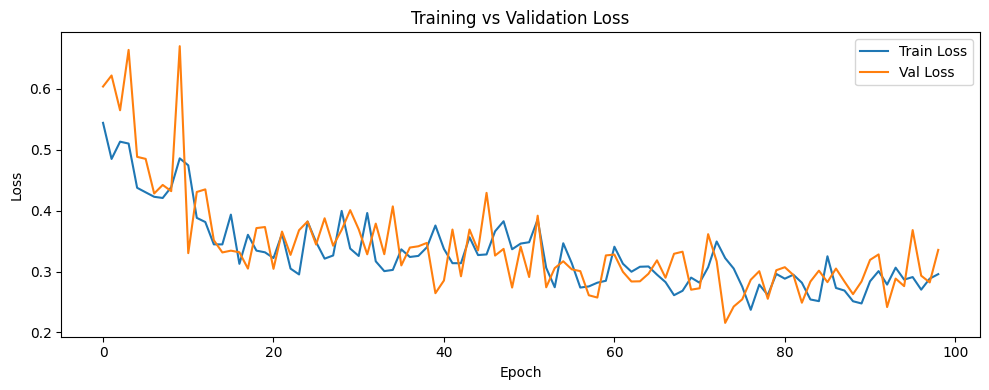

In [16]:
from matplotlib import pyplot as plt

# ==============================
# CONFIG
# ==============================
EPOCHS       = 200
LOOKBACK     = 144
SITE_BATCH   = 16
WINDOW_BATCH = 32
SPATIAL_ITER = 60

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

scaler_amp       = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
loss_fn_per_step = nn.MSELoss(reduction='none')
step_weights     = torch.tensor([0.25, 0.20, 0.18, 0.15, 0.12, 0.10], device=device)


# ==============================
# LAT/LON CACHE
# ==============================
latlon = {s: get_lat_lon(s) for s in train_sites + val_sites + test_sites}

# ==============================
# INIT TRACKING
# ==============================
train_losses     = []
val_losses       = []
best_val_loss    = float("inf")
patience         = 25
patience_counter = 0

# ==============================
# TRAIN LOOP
# ==============================
for epoch in range(EPOCHS):

    model.train()
    epoch_loss = 0
    steps      = 0

    random.seed(epoch)  # reproducible train sampling

    for _ in range(SPATIAL_ITER):

        sampled_sites = random.sample(train_sites, SITE_BATCH)

        series_batch = []
        valid_sites  = []
        min_len      = float("inf")

        for s in sampled_sites:
            if s not in train_cache:
                continue
            series, ts = train_cache[s]
            if len(series) < LOOKBACK + WINDOW_BATCH + 8:
                continue
            series_batch.append((series, ts))
            valid_sites.append(s)
            min_len = min(min_len, len(series))

        if len(valid_sites) < 5:
            continue

        A = build_graph(valid_sites, k=4)

        max_start = int(min_len - (LOOKBACK + WINDOW_BATCH + 8))
        if max_start <= 0:
            continue

        start_idx = random.randint(0, max_start)

        X_list, y_list = [], []

        for s, (series, ts) in zip(valid_sites, series_batch):
            lat, lon = latlon[s]
            seg_series = series[start_idx:start_idx + LOOKBACK + WINDOW_BATCH + 8]
            seg_ts     = ts[start_idx:start_idx + LOOKBACK + WINDOW_BATCH + 8]
            X_site, y_site = make_windows(seg_series, seg_ts, lat, lon, LOOKBACK)
            if len(X_site) < WINDOW_BATCH:
                continue
            X_list.append(X_site[:WINDOW_BATCH])
            y_list.append(y_site[:WINDOW_BATCH])

        if len(X_list) < 3:
            continue

        X = np.stack(X_list, axis=2).astype(np.float32)   # (B, T, N, F)
        y = np.stack(y_list, axis=1).astype(np.float32)   # (B, N, 6)

        xb = torch.from_numpy(X).to(device)
        yb = torch.from_numpy(y).to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            pred = model(xb, A)                            # (B, N, 6)
            loss = loss_fn_per_step(pred, yb)              # (B, N, 6)
            loss = loss.mean(dim=(0, 1))                   # (6,)
            loss = (loss * step_weights).sum()             # scalar

        scaler_amp.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()

        epoch_loss += loss.item()
        steps      += 1

    scheduler.step()
    avg_loss = epoch_loss / max(steps, 1)

    # ==============================
    # VALIDATION
    # ==============================
    model.eval()
    val_loss  = 0
    val_steps = 0

    random.seed(epoch + 1000)  # deterministic per epoch

    with torch.no_grad():
        for _ in range(15):

            sampled_sites = random.sample(val_sites, SITE_BATCH)

            series_batch = []
            valid_sites  = []
            min_len      = float("inf")

            for s in sampled_sites:
                if s not in val_cache:
                    continue
                series, ts = val_cache[s]
                if len(series) < LOOKBACK + WINDOW_BATCH + 8:
                    continue
                series_batch.append((series, ts))
                valid_sites.append(s)
                min_len = min(min_len, len(series))

            if len(valid_sites) < 5:
                continue

            A = build_graph(valid_sites, k=4)

            max_start = int(min_len - (LOOKBACK + WINDOW_BATCH + 8))
            if max_start <= 0:
                continue

            start_idx = random.randint(0, max_start)

            X_list, y_list = [], []

            for s, (series, ts) in zip(valid_sites, series_batch):
                lat, lon = latlon[s]
                seg_series = series[start_idx:start_idx + LOOKBACK + WINDOW_BATCH + 8]
                seg_ts     = ts[start_idx:start_idx + LOOKBACK + WINDOW_BATCH + 8]
                X_site, y_site = make_windows(seg_series, seg_ts, lat, lon, LOOKBACK)
                if len(X_site) < WINDOW_BATCH:
                    continue
                X_list.append(X_site[:WINDOW_BATCH])
                y_list.append(y_site[:WINDOW_BATCH])

            if len(X_list) < 3:
                continue

            X = np.stack(X_list, axis=2).astype(np.float32)
            y = np.stack(y_list, axis=1).astype(np.float32)

            xb = torch.from_numpy(X).to(device)
            yb = torch.from_numpy(y).to(device)

            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                pred = model(xb, A)
                loss = loss_fn_per_step(pred, yb)
                loss = loss.mean(dim=(0, 1))
                loss = (loss * step_weights).sum()

            val_loss  += loss.item()
            val_steps += 1

    random.seed(epoch)  # restore train randomness

    val_loss = val_loss / max(val_steps, 1)

    train_losses.append(avg_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {avg_loss:.4f} | Val: {val_loss:.4f}")

    # ==============================
    # EARLY STOPPING
    # ==============================
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  ✔ Best model saved (val={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# ==============================
# LOAD BEST MODEL
# ==============================
model.load_state_dict(torch.load("best_model.pt"))
model.eval()
print("Best model loaded")

# ==============================
# LOSS CURVE
# ==============================
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

Evaluating site 1/39
Evaluating site 2/39
Evaluating site 3/39
Evaluating site 4/39
Evaluating site 5/39
Evaluating site 6/39
Evaluating site 7/39
Evaluating site 8/39
Evaluating site 9/39
Evaluating site 10/39
Evaluating site 11/39
Evaluating site 12/39
Evaluating site 13/39
Evaluating site 14/39
Evaluating site 15/39
Evaluating site 16/39
Evaluating site 17/39
Evaluating site 18/39
Evaluating site 19/39
Evaluating site 20/39
Evaluating site 21/39
Evaluating site 22/39
Evaluating site 23/39
Evaluating site 24/39
Evaluating site 25/39
Evaluating site 26/39
Evaluating site 27/39
Evaluating site 28/39
Evaluating site 29/39
Evaluating site 30/39
Evaluating site 31/39
Evaluating site 32/39
Evaluating site 33/39
Evaluating site 34/39
Evaluating site 35/39
Evaluating site 36/39
Evaluating site 37/39
Evaluating site 38/39
Evaluating site 39/39
       FINAL EVALUATION METRICS
  RMSE              : 1.8066 m/s
  MAE               : 1.3092 m/s
  R²                : 0.7652
  MAPE              : 23

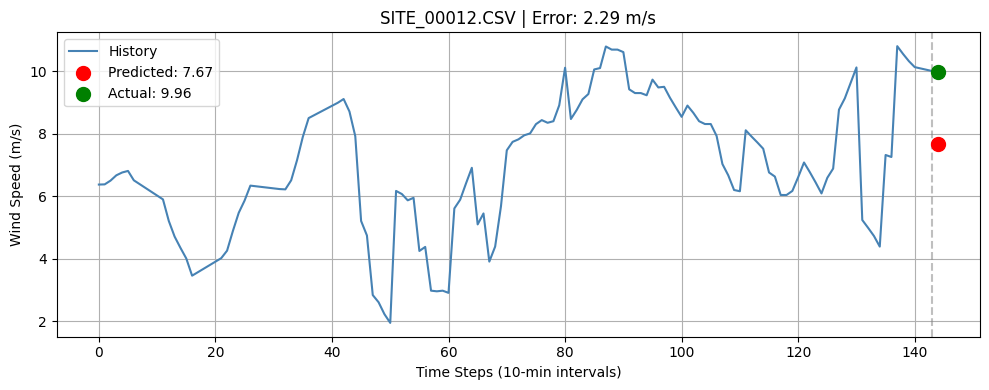

Random start index: 113218
Predicted : 9.12 m/s
Actual    : 11.27 m/s
Error     : 2.15 m/s


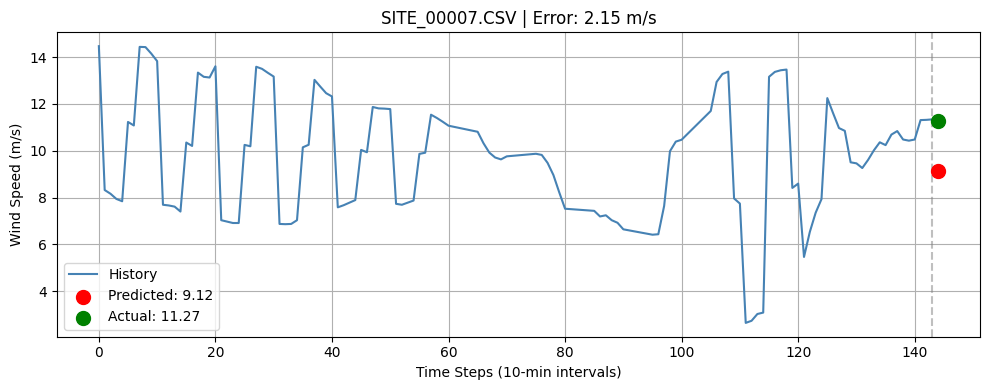

Random start index: 100764
Predicted : 7.26 m/s
Actual    : 6.30 m/s
Error     : 0.96 m/s


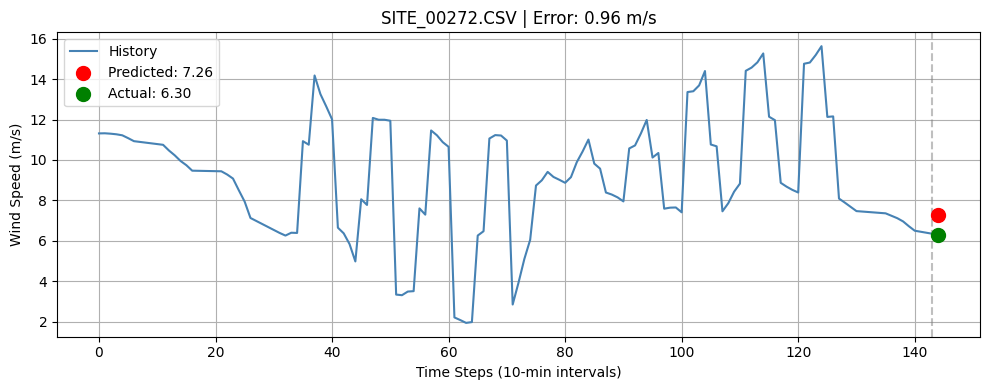

Random start index: 107041
Predicted : 6.65 m/s
Actual    : 7.20 m/s
Error     : 0.55 m/s


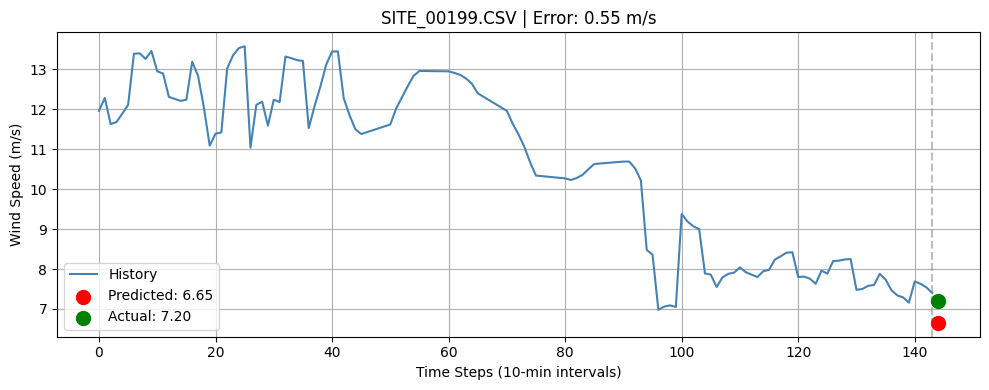

Random start index: 112224
Predicted : 6.62 m/s
Actual    : 5.62 m/s
Error     : 1.00 m/s


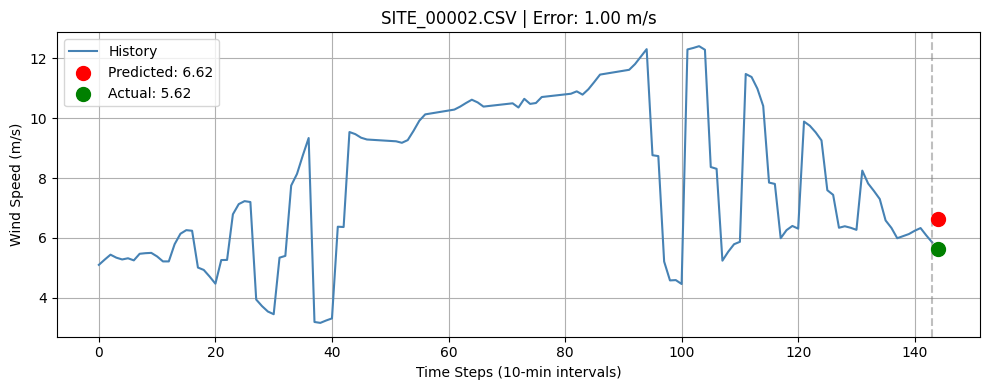


--- 6-STEP INSPECTION ---


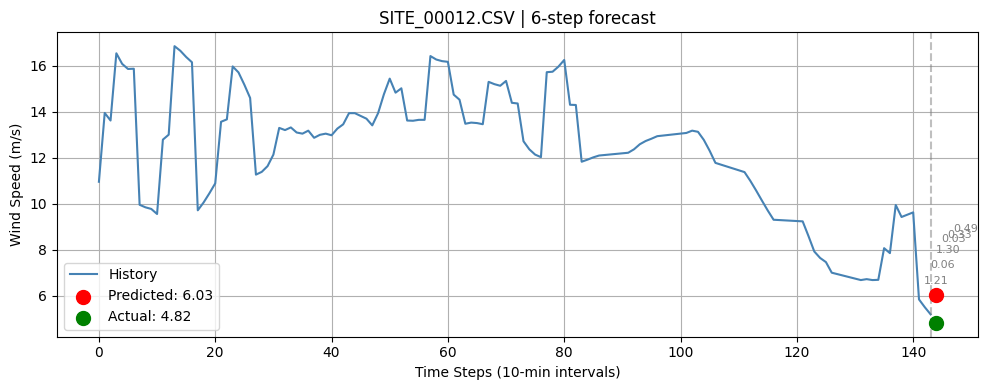

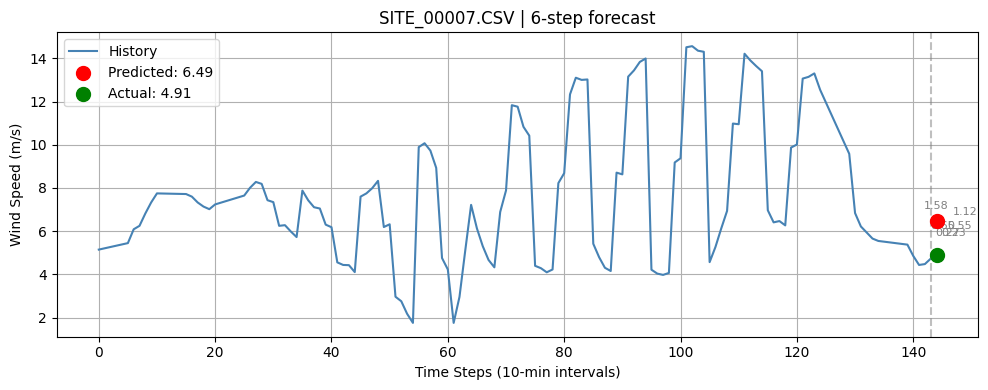

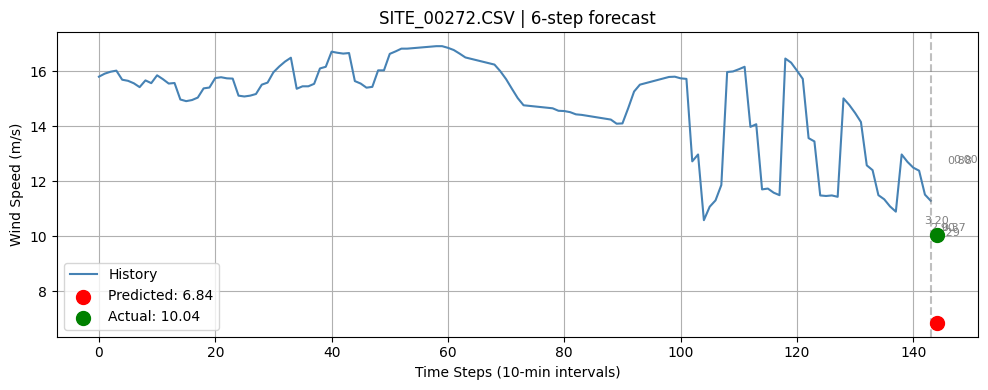

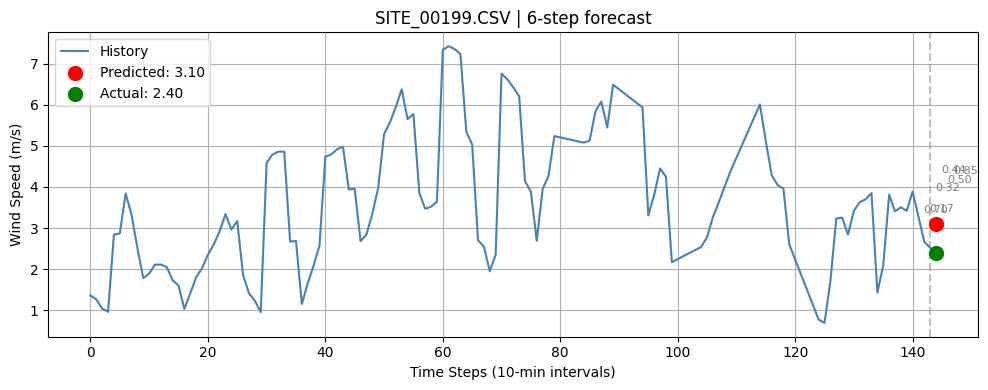

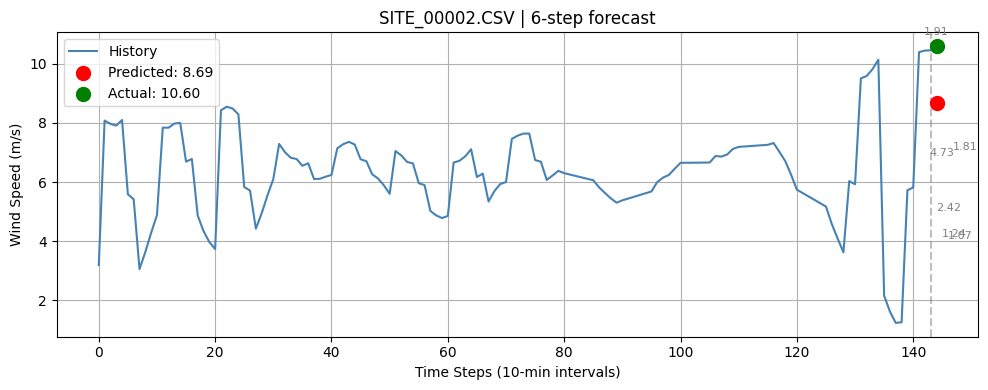

In [17]:
# ==============================
# 1-STEP EVALUATION
# ==============================
from sklearn.metrics import r2_score, mean_absolute_error

k_eval           = 4
TEMPORAL_SAMPLES = 150

sq_errors = []
preds     = []
trues     = []

model.eval()
np.random.seed(42)

for idx, test_site in enumerate(test_sites):

    print(f"Evaluating site {idx+1}/{len(test_sites)}")

    lat_t, lon_t = latlon.get(test_site, (None, None))
    if lat_t is None:
        continue

    dists = []
    for s in train_sites:
        lat, lon = latlon.get(s, (None, None))
        if lat is None:
            continue
        d = haversine(lat_t, lon_t, lat, lon)
        dists.append((s, d))

    neighbors   = [x[0] for x in sorted(dists, key=lambda x: x[1])[:k_eval]]
    batch_sites = neighbors + [test_site]

    series_batch = []
    ts_batch     = []

    for s in batch_sites:
        if s in train_cache:
            series, ts = train_cache[s]
        elif s in val_cache:
            series, ts = val_cache[s]
        elif s in test_cache:
            series, ts = test_cache[s]
        else:
            continue
        series_batch.append(series)
        ts_batch.append(ts)

    if len(series_batch) < 2:
        continue

    valid_batch = batch_sites[:len(series_batch)]
    A = build_graph(valid_batch, k=4)

    max_len = min([len(s) for s in series_batch]) - LOOKBACK - 6  # fix 1
    if max_len <= 0:
        continue

    starts = np.random.randint(0, max_len, TEMPORAL_SAMPLES)

    for start in starts:

        X_list      = []
        y_true_wind = None

        for i, (series, ts) in enumerate(zip(series_batch, ts_batch)):

            window = series[start:start+LOOKBACK, 0]
            power  = series[start:start+LOOKBACK, 1]
            ts_w   = ts[start:start+LOOKBACK]

            roll_mean = pd.Series(window).rolling(12, min_periods=1).mean().values
            roll_std  = pd.Series(window).rolling(12, min_periods=1).std().fillna(0).values
            roll_max  = pd.Series(window).rolling(6,  min_periods=1).max().values
            roll_min  = pd.Series(window).rolling(6,  min_periods=1).min().values

            minutes  = (ts_w.hour*60 + ts_w.minute).values
            sin_day  = np.sin(2*np.pi*minutes/1440)
            cos_day  = np.cos(2*np.pi*minutes/1440)

            doy      = ts_w.dayofyear.values
            sin_year = np.sin(2*np.pi*doy/365)
            cos_year = np.cos(2*np.pi*doy/365)

            lag1  = np.roll(window, 1); lag1[0]  = lag1[1]
            lag2  = np.roll(window, 2); lag2[:2] = lag2[2]
            delta = window - np.roll(window, 1); delta[0] = 0

            lat_s, lon_s = latlon.get(valid_batch[i], (0, 0))
            lat_feat = np.full_like(window, (lat_s or 0) / 90.0)
            lon_feat = np.full_like(window, (lon_s or 0) / 180.0)

            feat = np.stack(
                [window, power, roll_mean, roll_std,
                 sin_day, cos_day, sin_year, cos_year,
                 lag1, lag2, delta,
                 roll_max, roll_min,
                 lat_feat, lon_feat],
                axis=1
            )

            X_list.append(feat)

            if i == len(series_batch) - 1:
                y_true_wind = series[start + LOOKBACK, 0]

        if len(X_list) < 2 or y_true_wind is None:
            continue

        X  = np.stack(X_list, axis=1)[np.newaxis].astype(np.float32)
        xb = torch.from_numpy(X).to(device)

        with torch.no_grad():
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                pred = model(xb, A).cpu().numpy()[0, -1]  # (6,)

        mean_s, std_s = site_scalers[test_site]
        pred_real = float(pred[0]) * float(std_s[0]) + float(mean_s[0])
        true_real = float(y_true_wind) * float(std_s[0]) + float(mean_s[0])

        sq_errors.append((pred_real - true_real) ** 2)
        preds.append(pred_real)
        trues.append(true_real)

preds_arr = np.array(preds)
trues_arr = np.array(trues)

rmse = np.sqrt(np.mean(sq_errors))
mae  = mean_absolute_error(trues_arr, preds_arr)
r2   = r2_score(trues_arr, preds_arr)

mask = trues_arr != 0
mape = np.mean(np.abs((trues_arr[mask] - preds_arr[mask]) / trues_arr[mask])) * 100

within   = np.abs(trues_arr - preds_arr) / (np.abs(trues_arr) + 1e-8)
acc_10   = np.mean(within <= 0.10) * 100
acc_15   = np.mean(within <= 0.15) * 100
acc_20   = np.mean(within <= 0.20) * 100
acc_25   = np.mean(within <= 0.25) * 100
acc_30   = np.mean(within <= 0.30) * 100

abs_errors = np.abs(trues_arr - preds_arr)
acc_1ms  = np.mean(abs_errors <= 1.0) * 100
acc_2ms  = np.mean(abs_errors <= 2.0) * 100
acc_3ms  = np.mean(abs_errors <= 3.0) * 100

persist_rmse = np.sqrt(np.mean((trues_arr[1:] - trues_arr[:-1])**2))
improvement  = ((persist_rmse - rmse) / persist_rmse) * 100

print("=" * 50)
print("       FINAL EVALUATION METRICS")
print("=" * 50)
print(f"  RMSE              : {rmse:.4f} m/s")
print(f"  MAE               : {mae:.4f} m/s")
print(f"  R²                : {r2:.4f}")
print(f"  MAPE              : {mape:.2f} %")
print("-" * 50)
print("  PERCENTAGE ACCURACY")
print(f"  Within 10%        : {acc_10:.2f} %")
print(f"  Within 15%        : {acc_15:.2f} %")
print(f"  Within 20%        : {acc_20:.2f} %")
print(f"  Within 25%        : {acc_25:.2f} %")
print(f"  Within 30%        : {acc_30:.2f} %")
print("-" * 50)
print("  ABSOLUTE ERROR ACCURACY")
print(f"  Within ±1.0 m/s   : {acc_1ms:.2f} %")
print(f"  Within ±2.0 m/s   : {acc_2ms:.2f} %")
print(f"  Within ±3.0 m/s   : {acc_3ms:.2f} %")
print("-" * 50)
print("  BASELINE COMPARISON")
print(f"  Persistence RMSE  : {persist_rmse:.4f} m/s")
print(f"  ST-LSTM RMSE      : {rmse:.4f} m/s")
print(f"  Improvement       : {improvement:.2f} %")
print(f"  Sites evaluated   : {len(test_sites)}")
print(f"  Total samples     : {len(sq_errors)}")
print("=" * 50)


# ==============================
# 6-STEP EVALUATION
# ==============================
from sklearn.metrics import mean_squared_error

all_preds = []
all_trues = []

model.eval()
np.random.seed(42)

for test_site in test_sites:

    lat_t, lon_t = latlon.get(test_site, (None, None))
    if lat_t is None:
        continue

    dists = []
    for s in train_sites:
        lat, lon = latlon.get(s, (None, None))
        if lat is None:
            continue
        d = haversine(lat_t, lon_t, lat, lon)
        dists.append((s, d))

    if len(dists) < 4:
        continue

    neighbors   = [x[0] for x in sorted(dists, key=lambda x: x[1])[:4]]
    batch_sites = neighbors + [test_site]

    series_list = []
    ts_list     = []

    for s in batch_sites:
        if s in train_cache:
            series, ts = train_cache[s]
        elif s in val_cache:                    # fix 5
            series, ts = val_cache[s]
        elif s in test_cache:
            series, ts = test_cache[s]
        else:
            continue
        series_list.append(series)
        ts_list.append(ts)

    if len(series_list) < 2:
        continue

    valid_batch = batch_sites[:len(series_list)]
    A = build_graph(valid_batch, k=4)

    max_len = min([len(s) for s in series_list]) - LOOKBACK - 6
    if max_len <= 0:
        continue

    starts = np.random.randint(0, max_len, 150)  # fix 3

    for start in starts:

        X_list = []
        y_true = None                            # fix 4

        for i, (series, ts) in enumerate(zip(series_list, ts_list)):

            lat_s, lon_s = latlon.get(valid_batch[i], (0, 0))

            X_s, y_s = make_windows(
                series[start:start+LOOKBACK+7],
                ts[start:start+LOOKBACK+7],
                lat_s, lon_s,
                LOOKBACK
            )

            if len(X_s) == 0:
                continue

            X_list.append(X_s[0])

            if i == len(series_list) - 1:
                y_true = y_s[0]                 # (6,)

        if len(X_list) < 2 or y_true is None:   # fix 4
            continue

        X  = np.stack(X_list, axis=1)[np.newaxis].astype(np.float32)
        xb = torch.from_numpy(X).to(device)

        with torch.no_grad():
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                pred = model(xb, A).cpu().numpy()[0, -1]  # (6,)

        mean_s, std_s = site_scalers[test_site]
        pred_real = pred   * float(std_s[0]) + float(mean_s[0])
        true_real = y_true * float(std_s[0]) + float(mean_s[0])

        all_preds.append(pred_real)
        all_trues.append(true_real)

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)

print("\n========== 6-STEP METRICS ==========\n")
for i in range(6):
    rmse = np.sqrt(mean_squared_error(all_trues[:, i], all_preds[:, i]))
    r2   = r2_score(all_trues[:, i], all_preds[:, i])
    print(f"Step {i+1}: RMSE = {rmse:.4f}, R² = {r2:.4f}")

rmse_all = np.sqrt(mean_squared_error(all_trues.flatten(), all_preds.flatten()))
r2_all   = r2_score(all_trues.flatten(), all_preds.flatten())

print("\n---------- OVERALL ----------")
print(f"RMSE (all steps): {rmse_all:.4f}")
print(f"R²   (all steps): {r2_all:.4f}")


# ==============================
# INSPECT 1-STEP
# ==============================
def inspect_site_spatial_random(site, k_context=4, start=None):

    lat_t, lon_t = latlon.get(site, (None, None))
    if lat_t is None:
        print(f"Missing coordinates for {site}")
        return

    dists = []
    for s in train_sites:
        lat, lon = latlon.get(s, (None, None))
        if lat is None:
            continue
        d = haversine(lat_t, lon_t, lat, lon)
        dists.append((s, d))

    if len(dists) < k_context:
        print("Not enough neighbors")
        return

    neighbors   = [x[0] for x in sorted(dists, key=lambda x: x[1])[:k_context]]
    batch_sites = neighbors + [site]

    series_list = []
    ts_list     = []

    for s in batch_sites:
        if s in train_cache:
            series, ts = train_cache[s]
        elif s in val_cache:                    # fix 5
            series, ts = val_cache[s]
        elif s in test_cache:
            series, ts = test_cache[s]
        else:
            continue
        series_list.append(series)
        ts_list.append(ts)

    if len(series_list) < 2:
        print("Not enough sites loaded")
        return

    valid_batch = batch_sites[:len(series_list)]
    A = build_graph(valid_batch, k=k_context)

    max_len = min([len(s) for s in series_list]) - LOOKBACK - 6
    if max_len <= 0:
        print("Series too short")
        return

    if start is None:
        start = np.random.randint(0, max_len)

    print(f"Random start index: {start}")

    X_list = []

    for i, (series, ts) in enumerate(zip(series_list, ts_list)):
        lat_s, lon_s = latlon.get(valid_batch[i], (0, 0))
        X_s, _ = make_windows(
            series[start:start+LOOKBACK+7],
            ts[start:start+LOOKBACK+7],
            lat_s, lon_s,
            LOOKBACK
        )
        if len(X_s) == 0:
            print(f"Empty window for site {i}")
            return
        X_list.append(X_s[0])

    X  = np.stack(X_list, axis=1)[np.newaxis].astype(np.float32)
    xb = torch.from_numpy(X).to(device)

    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            pred_all = model(xb, A).cpu().numpy()[0, -1]  # (6,)

    pred_val    = pred_all[0]
    true_val    = series_list[-1][start + LOOKBACK, 0]
    mean_s, std_s = site_scalers[site]
    pred_real   = float(pred_val)  * float(std_s[0]) + float(mean_s[0])
    true_real   = float(true_val)  * float(std_s[0]) + float(mean_s[0])

    history_scaled = series_list[-1][start:start+LOOKBACK, 0]
    history_real   = history_scaled * float(std_s[0]) + float(mean_s[0])

    print(f"Predicted : {pred_real:.2f} m/s")
    print(f"Actual    : {true_real:.2f} m/s")
    print(f"Error     : {abs(pred_real - true_real):.2f} m/s")

    plt.figure(figsize=(10, 4))
    plt.plot(range(LOOKBACK), history_real, label="History", color="steelblue")
    plt.scatter(LOOKBACK, pred_real, color="red",   s=100, zorder=5, label=f"Predicted: {pred_real:.2f}")
    plt.scatter(LOOKBACK, true_real, color="green", s=100, zorder=5, label=f"Actual: {true_real:.2f}")
    plt.axvline(x=LOOKBACK-1, linestyle="--", alpha=0.5, color="gray")
    plt.title(f"{os.path.basename(site)} | Error: {abs(pred_real-true_real):.2f} m/s")
    plt.xlabel("Time Steps (10-min intervals)")
    plt.ylabel("Wind Speed (m/s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ==============================
# INSPECT 6-STEP
# ==============================
def inspect_site_6step(site, k_context=4, start=None):

    lat_t, lon_t = latlon.get(site, (None, None))
    if lat_t is None:
        print("Missing coordinates")
        return

    dists = []
    for s in train_sites:
        lat, lon = latlon.get(s, (None, None))
        if lat is None:
            continue
        d = haversine(lat_t, lon_t, lat, lon)
        dists.append((s, d))

    neighbors   = [x[0] for x in sorted(dists, key=lambda x: x[1])[:k_context]]
    batch_sites = neighbors + [site]

    series_list = []
    ts_list     = []

    for s in batch_sites:
        if s in train_cache:
            series, ts = train_cache[s]
        elif s in val_cache:                    # fix 5
            series, ts = val_cache[s]
        elif s in test_cache:
            series, ts = test_cache[s]
        else:
            continue
        series_list.append(series)
        ts_list.append(ts)

    if len(series_list) < 2:
        return

    valid_batch = batch_sites[:len(series_list)]
    A = build_graph(valid_batch, k=k_context)

    max_len = min([len(s) for s in series_list]) - LOOKBACK - 6
    if max_len <= 0:
        return

    if start is None:
        start = np.random.randint(0, max_len)

    X_list = []
    y_true = None                               # fix 4

    for i, (series, ts) in enumerate(zip(series_list, ts_list)):
        lat_s, lon_s = latlon.get(valid_batch[i], (0, 0))
        X_s, y_s = make_windows(
            series[start:start+LOOKBACK+7],
            ts[start:start+LOOKBACK+7],
            lat_s, lon_s,
            LOOKBACK
        )
        if len(X_s) == 0:
            return
        X_list.append(X_s[0])
        if i == len(series_list) - 1:
            y_true = y_s[0]

    if y_true is None:                          # fix 4
        return

    X  = np.stack(X_list, axis=1)[np.newaxis].astype(np.float32)
    xb = torch.from_numpy(X).to(device)

    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            pred = model(xb, A).cpu().numpy()[0, -1]  # (6,)

    mean_s, std_s = site_scalers[site]
    pred_real = pred   * float(std_s[0]) + float(mean_s[0])
    true_real = y_true * float(std_s[0]) + float(mean_s[0])

    history = series_list[-1][start:start+LOOKBACK, 0]
    history = history * float(std_s[0]) + float(mean_s[0])

    plt.figure(figsize=(10, 4))
    plt.plot(range(LOOKBACK), history, label="History", color="steelblue")
    
    plt.scatter(LOOKBACK, pred_real[0], color="red",   s=100, zorder=5, label=f"Predicted: {pred_real[0]:.2f}")
    plt.scatter(LOOKBACK, true_real[0], color="green", s=100, zorder=5, label=f"Actual: {true_real[0]:.2f}")
    
    for i in range(6):
        err = abs(pred_real[i] - true_real[i])
        plt.annotate(
            f"{err:.2f}",
            xy=(LOOKBACK + i, max(pred_real[i], true_real[i])),
            xytext=(0, 8),
            textcoords="offset points",
            ha='center',
            fontsize=8,
            color="gray"
        )
    
    plt.axvline(x=LOOKBACK-1, linestyle="--", alpha=0.5, color="gray")
    plt.title(f"{os.path.basename(site)} | 6-step forecast")
    plt.xlabel("Time Steps (10-min intervals)")
    plt.ylabel("Wind Speed (m/s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ==============================
# RUN ON 5 RANDOM TEST SITES
# ==============================
sites_sample = random.sample(test_sites, 5)

print("\n--- 1-STEP INSPECTION ---")
for s in sites_sample:
    inspect_site_spatial_random(s)

print("\n--- 6-STEP INSPECTION ---")
for s in sites_sample:
    inspect_site_6step(s)

In [18]:
# add this right after training finishes
torch.save(model.state_dict(), "best_model_final.pt")

Random start index: 3114
Predicted : 10.22 m/s
Actual    : 9.16 m/s
Error     : 1.07 m/s


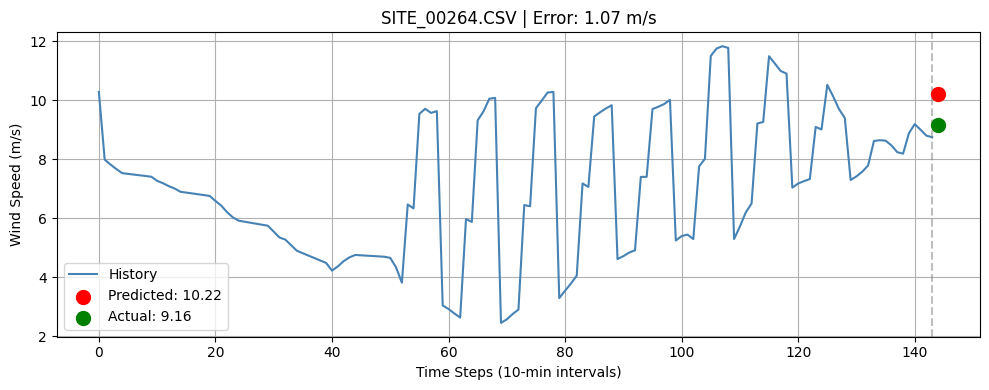

Random start index: 26502
Predicted : 7.91 m/s
Actual    : 5.32 m/s
Error     : 2.59 m/s


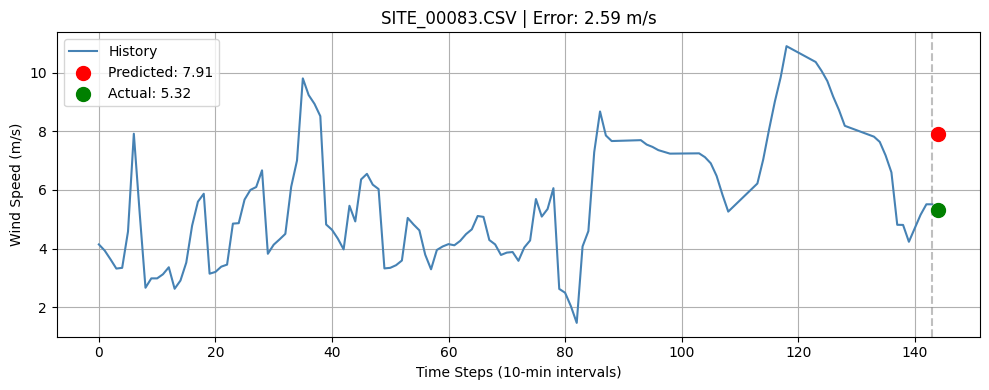

Random start index: 49768
Predicted : 11.11 m/s
Actual    : 7.91 m/s
Error     : 3.20 m/s


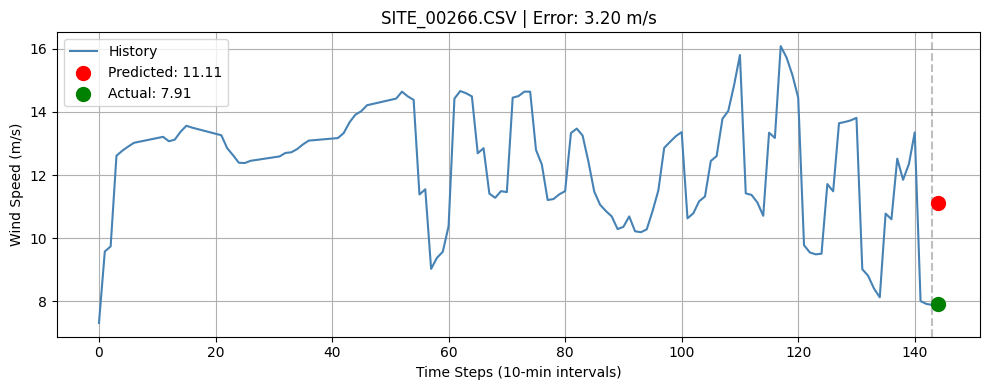

Random start index: 48128
Predicted : 10.50 m/s
Actual    : 10.79 m/s
Error     : 0.29 m/s


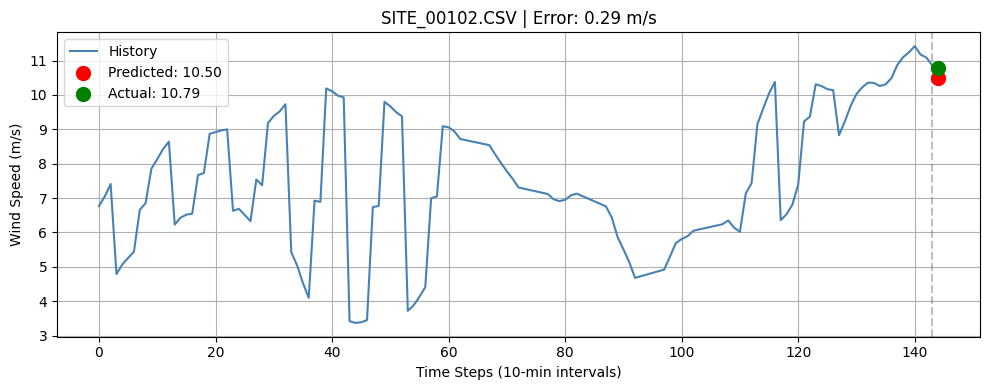

Random start index: 151100
Predicted : 6.50 m/s
Actual    : 6.06 m/s
Error     : 0.44 m/s


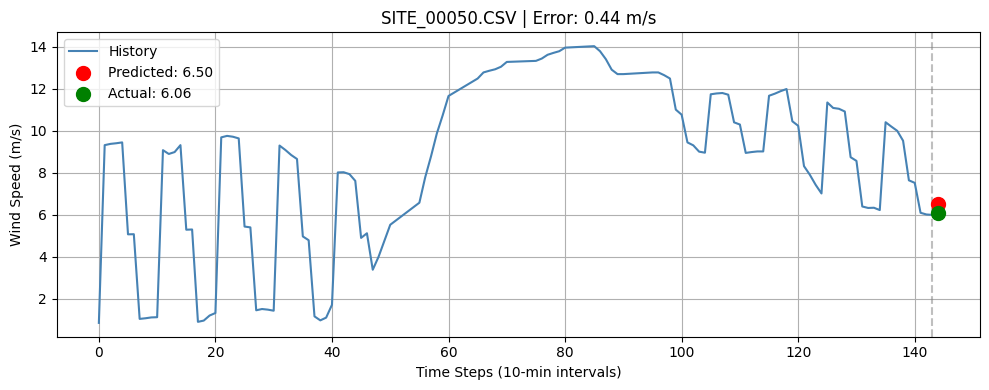

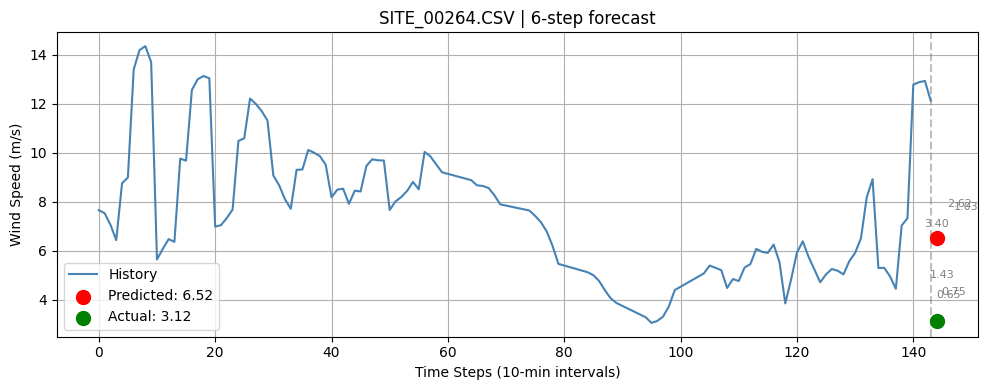

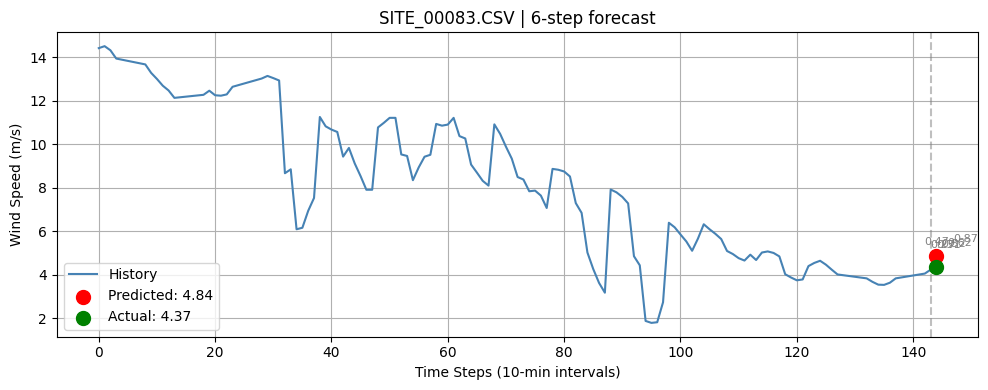

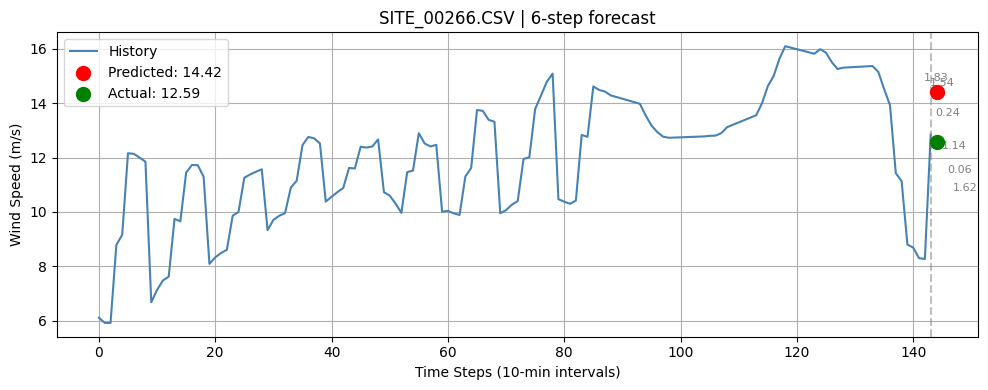

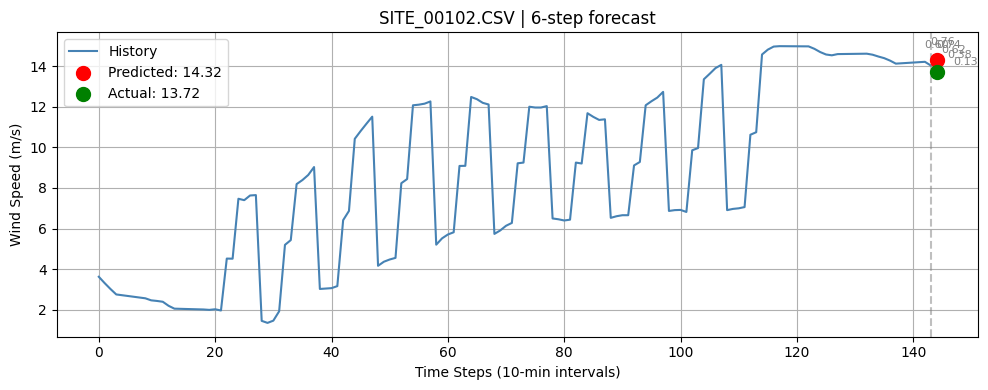

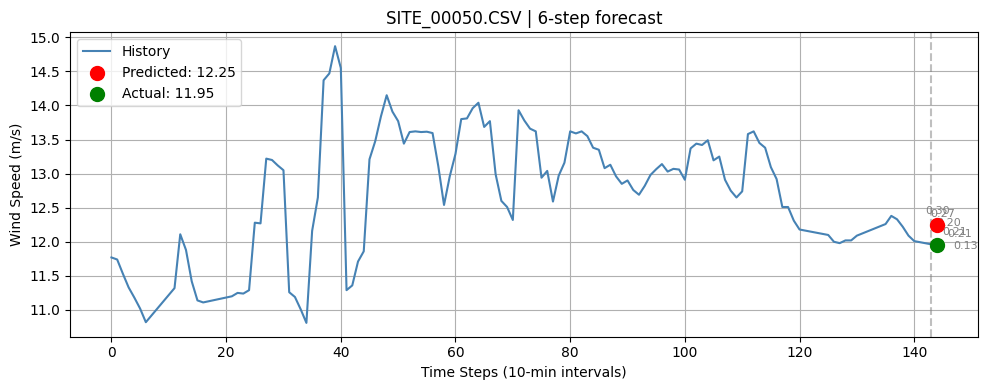

In [19]:
# 1-step plots
sites_sample = random.sample(test_sites, 5)
for s in sites_sample:
    inspect_site_spatial_random(s)

# 6-step plots
for s in sites_sample:
    inspect_site_6step(s)

Random start index: 135393
Predicted : 10.97 m/s
Actual    : 10.52 m/s
Error     : 0.45 m/s


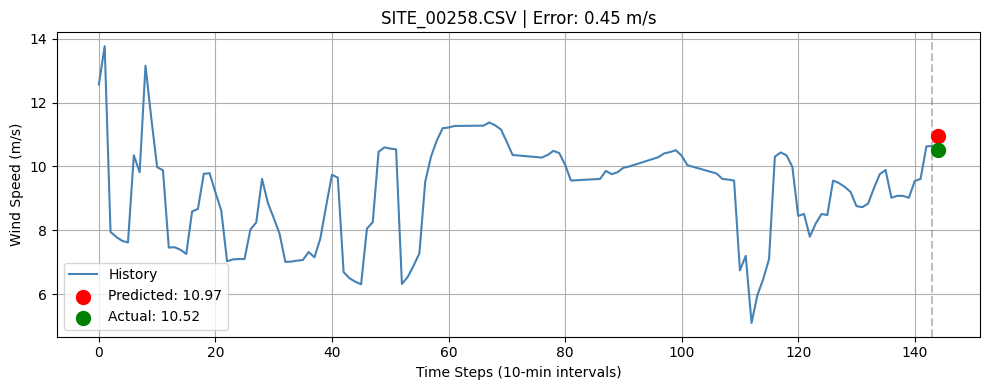

Random start index: 123549
Predicted : 8.09 m/s
Actual    : 8.76 m/s
Error     : 0.67 m/s


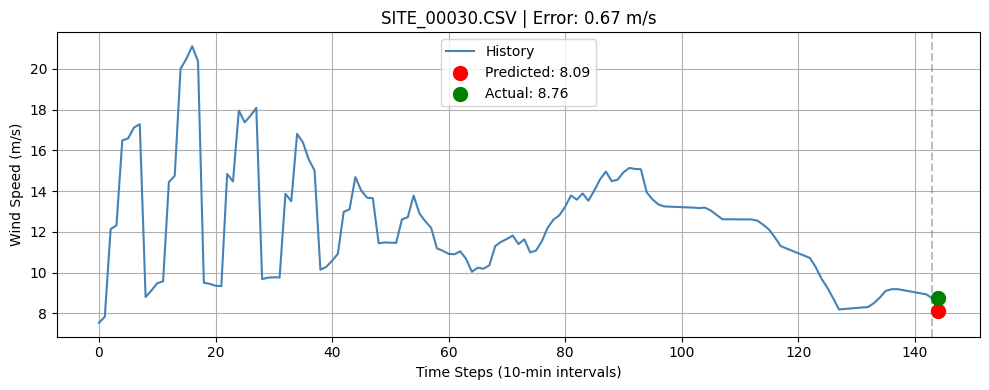

Random start index: 72635
Predicted : 6.04 m/s
Actual    : 7.60 m/s
Error     : 1.56 m/s


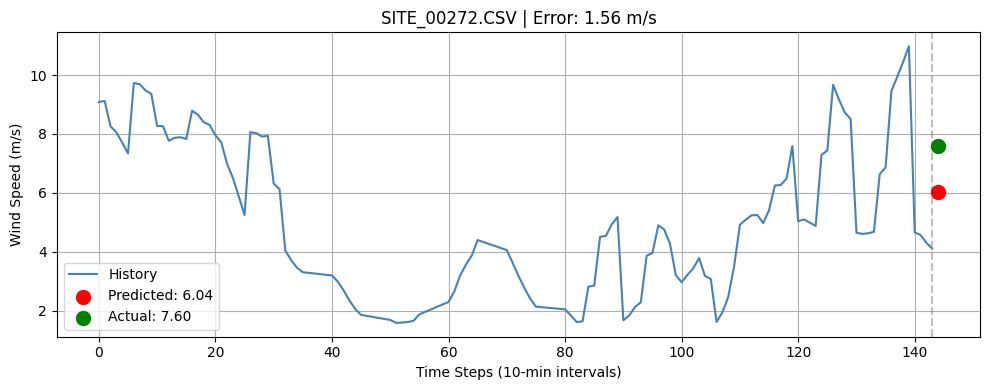

Random start index: 23760
Predicted : 7.78 m/s
Actual    : 6.85 m/s
Error     : 0.93 m/s


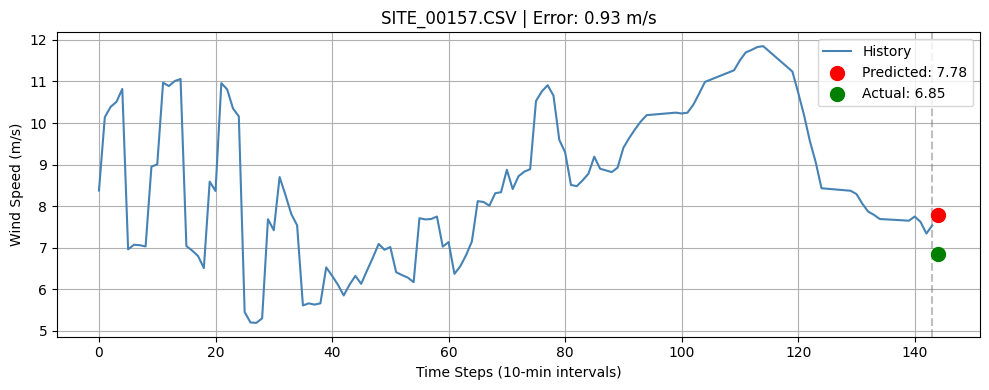

Random start index: 142432
Predicted : 14.52 m/s
Actual    : 13.39 m/s
Error     : 1.13 m/s


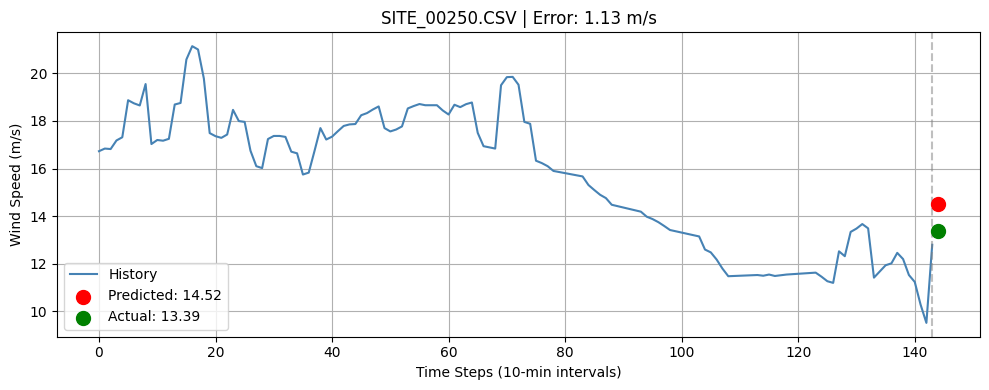

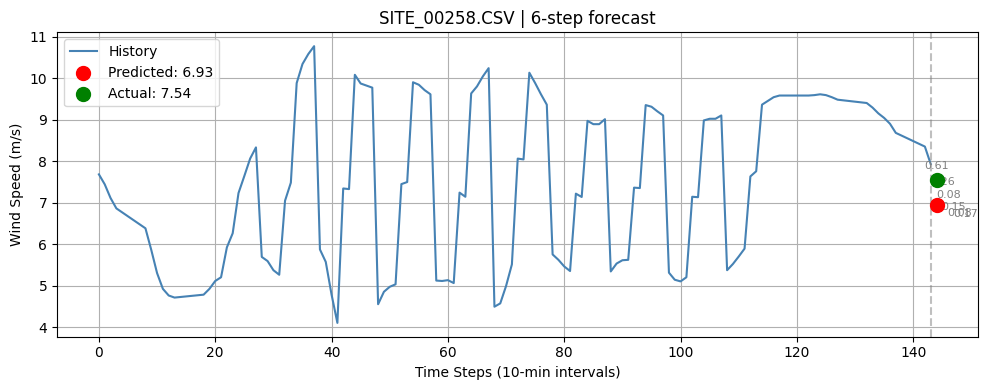

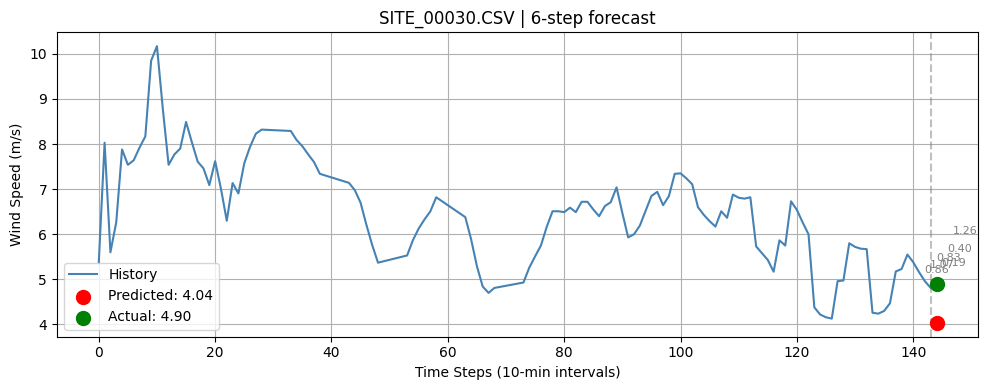

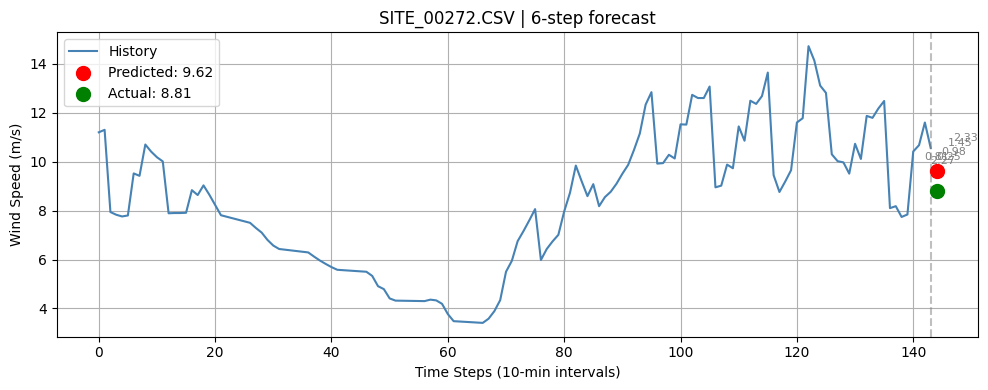

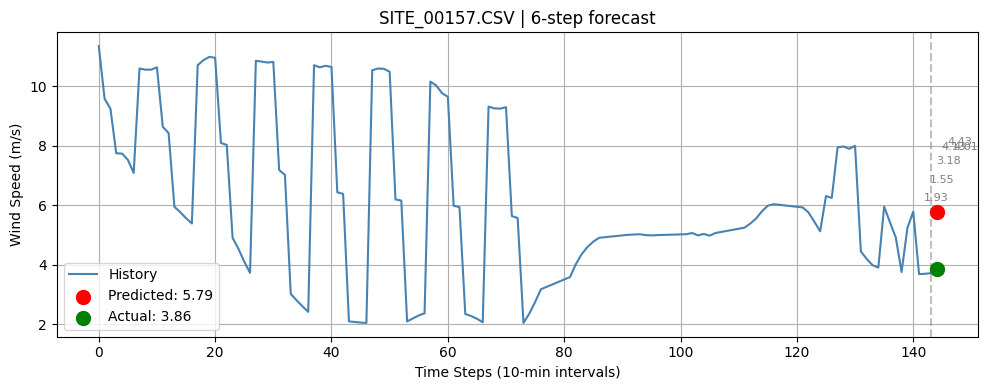

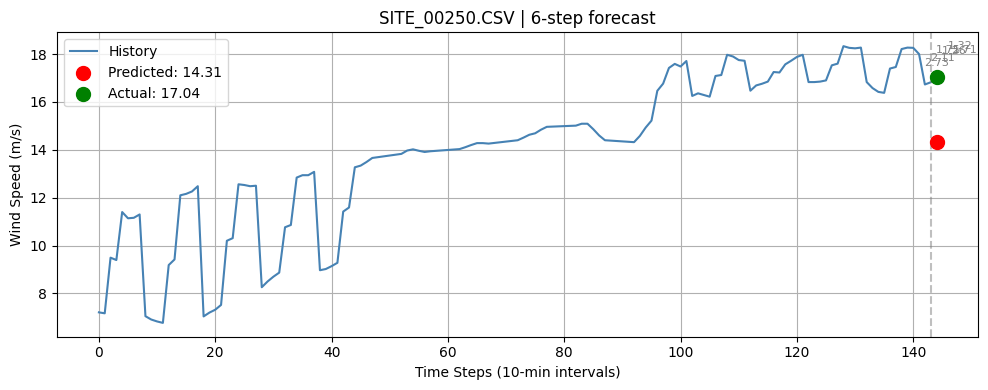

In [20]:
# 1-step plots
sites_sample = random.sample(test_sites, 5)
for s in sites_sample:
    inspect_site_spatial_random(s)

# 6-step plots
for s in sites_sample:
    inspect_site_6step(s)

Random start index: 147147
Predicted : 9.35 m/s
Actual    : 9.74 m/s
Error     : 0.39 m/s


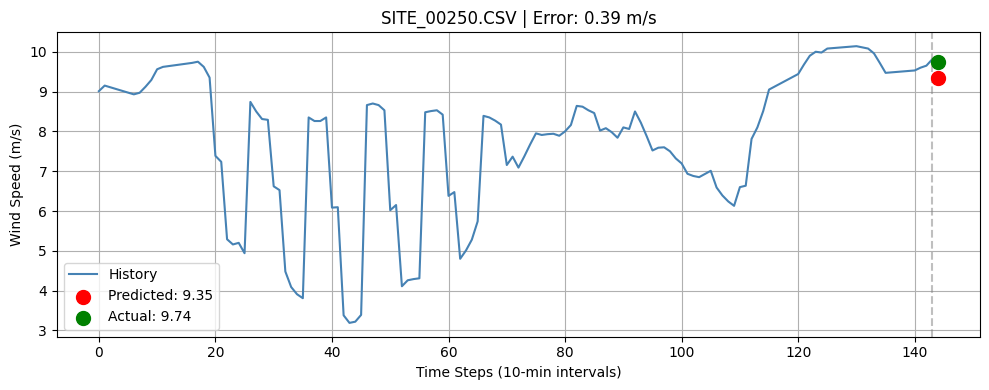

Random start index: 107215
Predicted : 7.90 m/s
Actual    : 8.64 m/s
Error     : 0.75 m/s


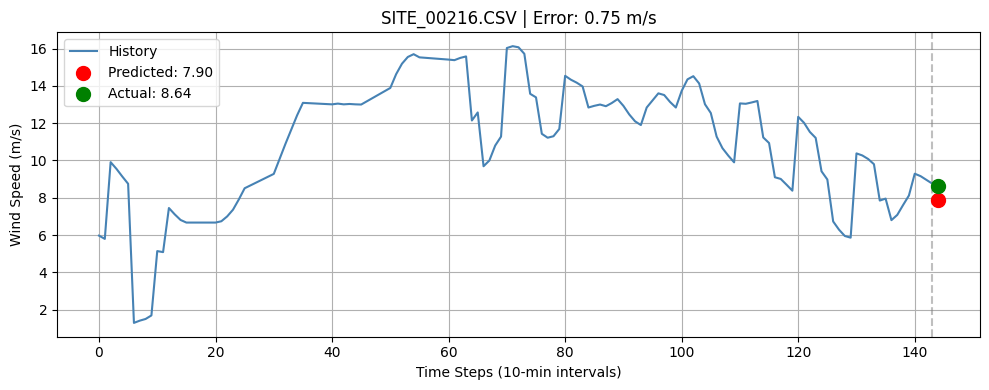

Random start index: 150056
Predicted : 11.09 m/s
Actual    : 12.56 m/s
Error     : 1.47 m/s


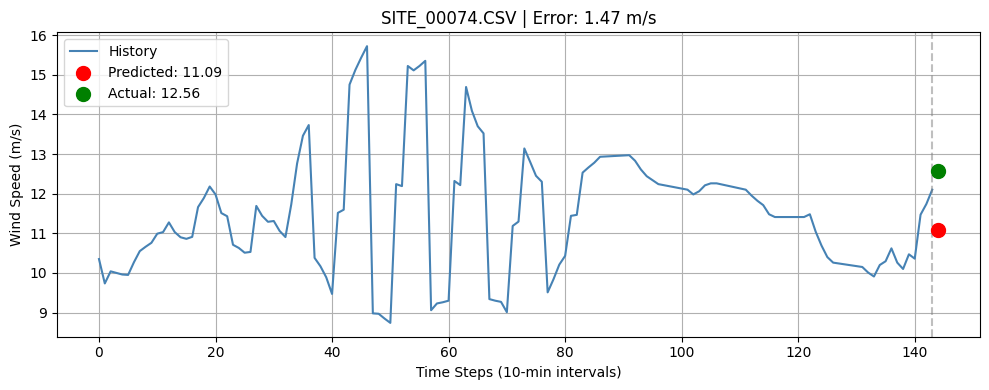

Random start index: 88095
Predicted : 13.55 m/s
Actual    : 10.83 m/s
Error     : 2.72 m/s


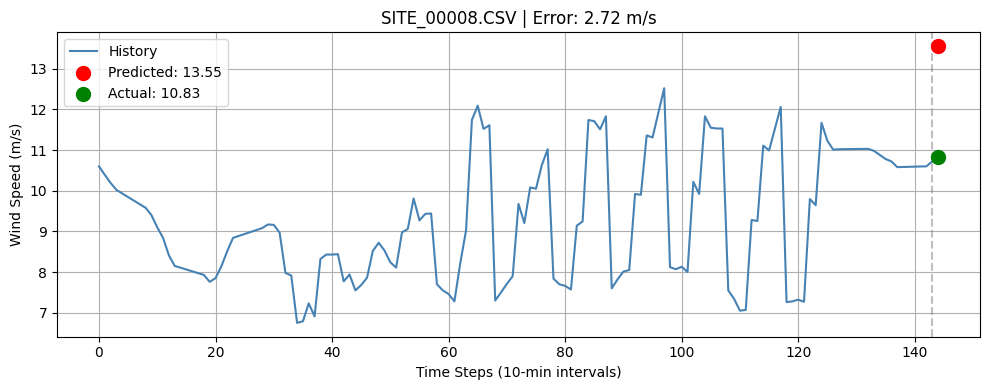

Random start index: 60942
Predicted : 6.73 m/s
Actual    : 7.46 m/s
Error     : 0.73 m/s


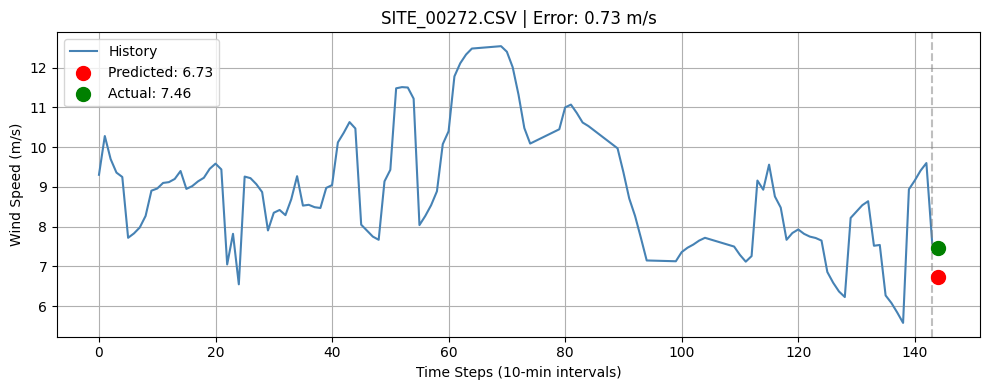

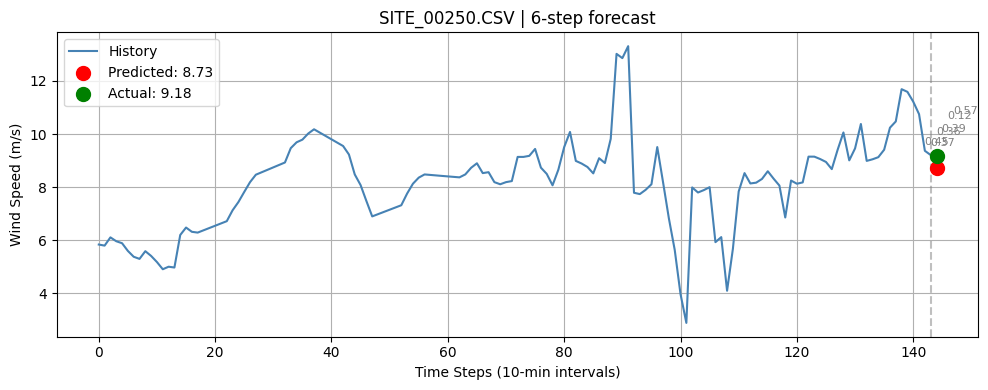

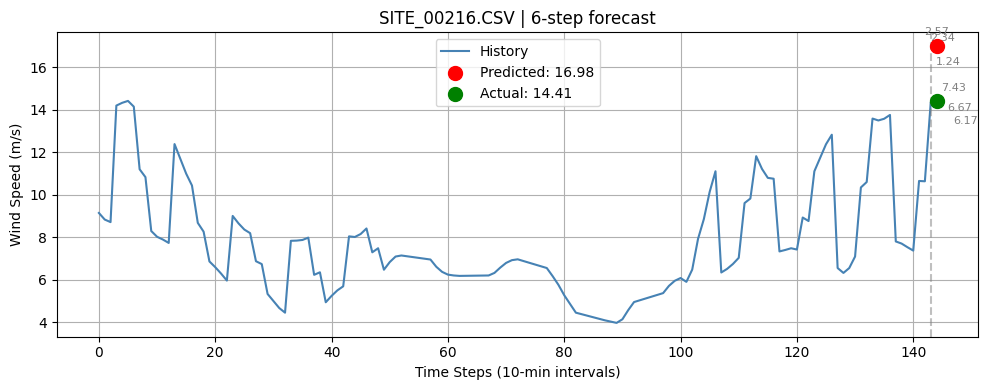

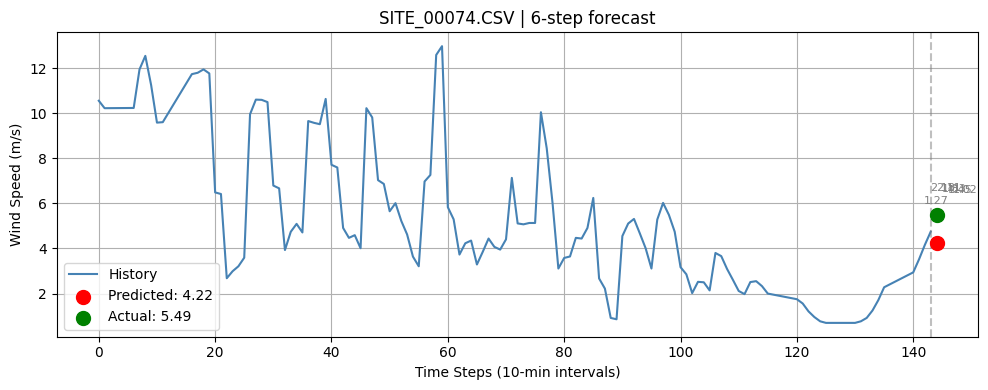

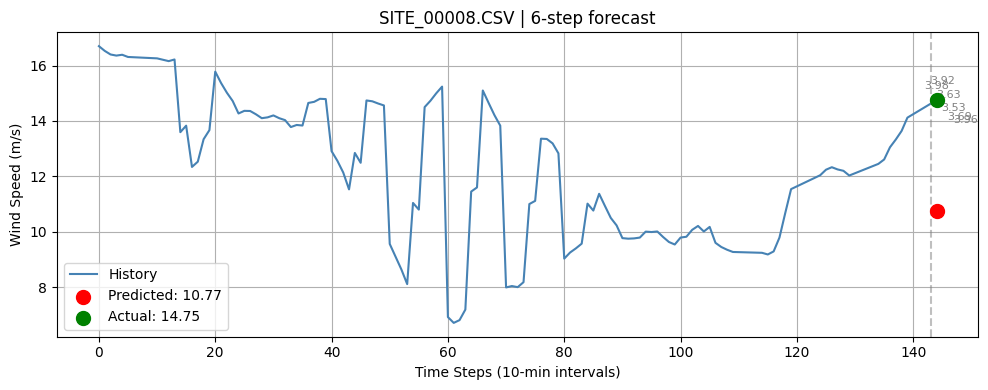

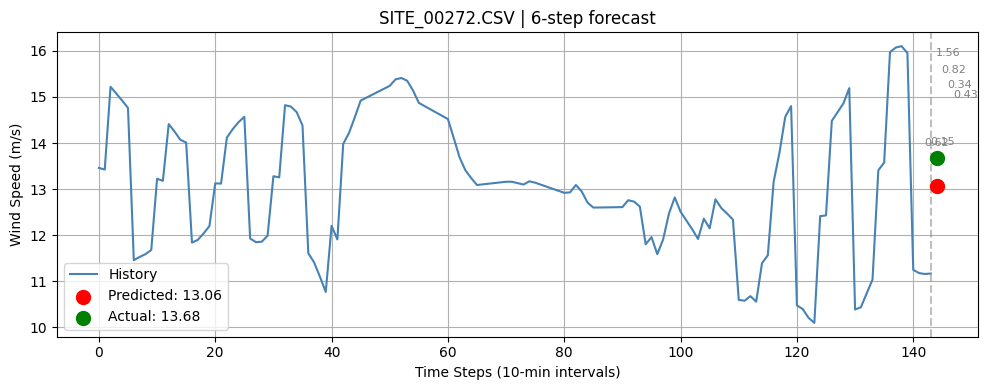

In [21]:
# 1-step plots
sites_sample = random.sample(test_sites, 5)
for s in sites_sample:
    inspect_site_spatial_random(s)

# 6-step plots
for s in sites_sample:
    inspect_site_6step(s)

Random start index: 72902
Predicted : 10.51 m/s
Actual    : 8.86 m/s
Error     : 1.65 m/s


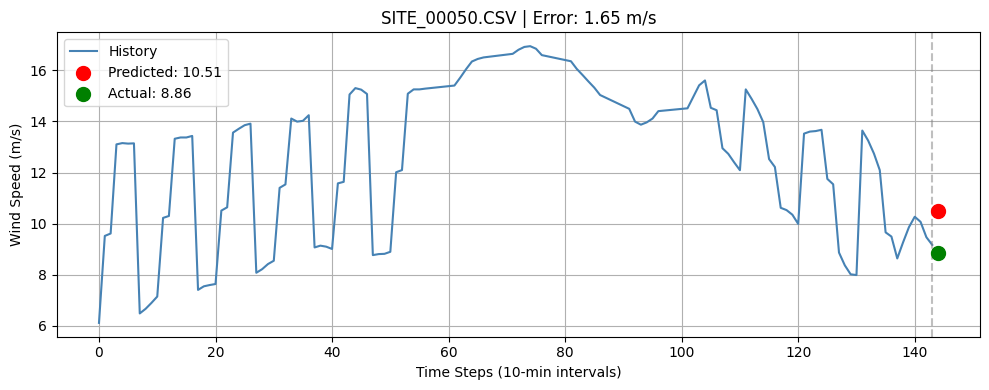

Random start index: 92172
Predicted : 6.52 m/s
Actual    : 9.87 m/s
Error     : 3.35 m/s


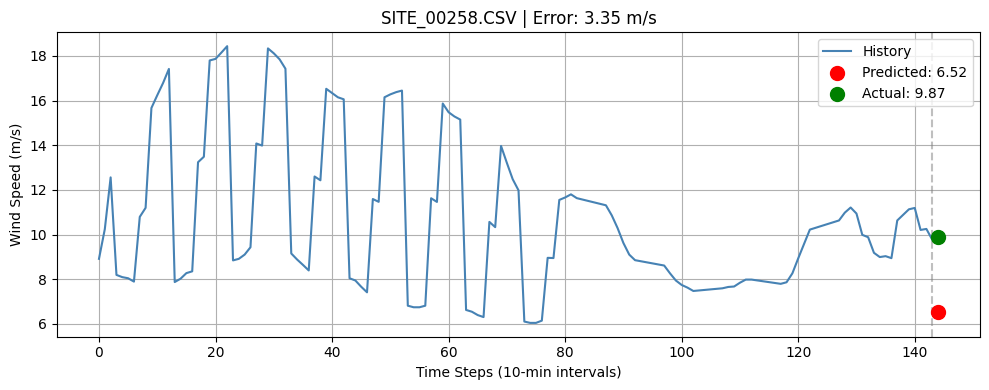

Random start index: 146702
Predicted : 7.93 m/s
Actual    : 6.23 m/s
Error     : 1.70 m/s


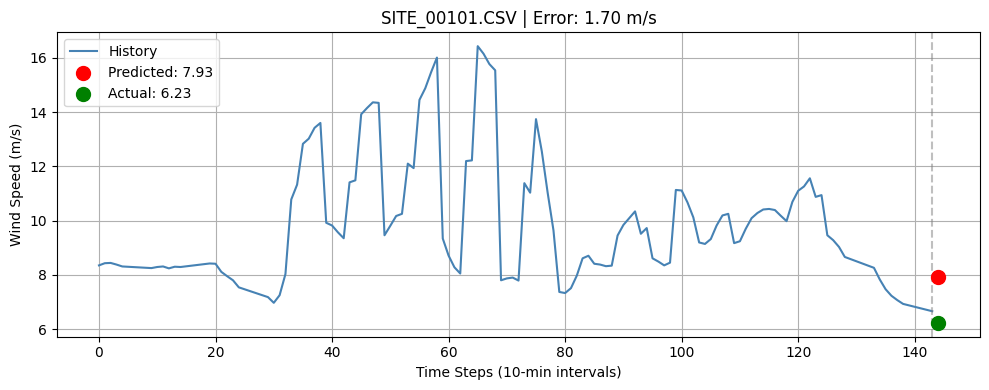

Random start index: 20056
Predicted : 8.01 m/s
Actual    : 8.46 m/s
Error     : 0.45 m/s


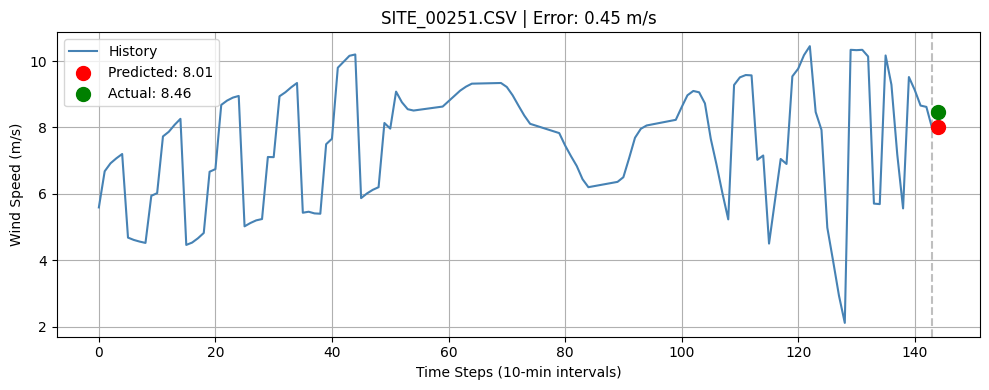

Random start index: 138454
Predicted : 7.98 m/s
Actual    : 7.63 m/s
Error     : 0.35 m/s


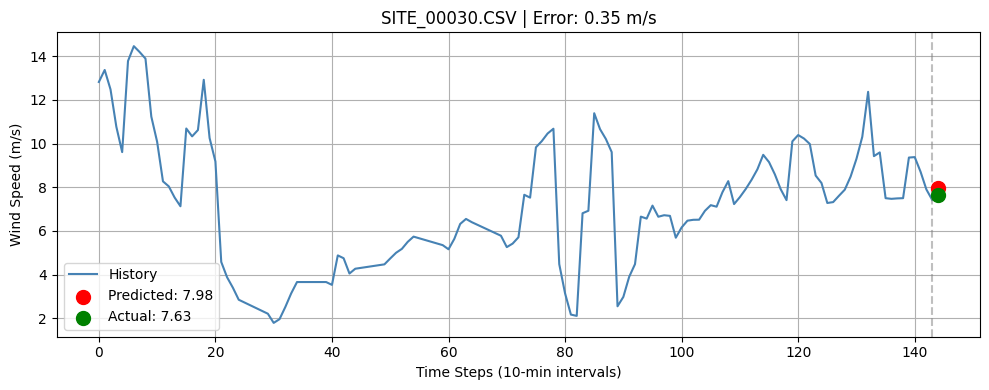

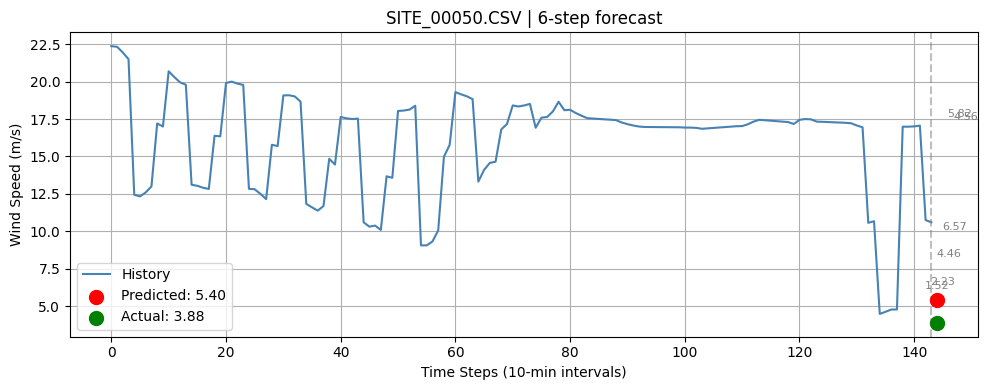

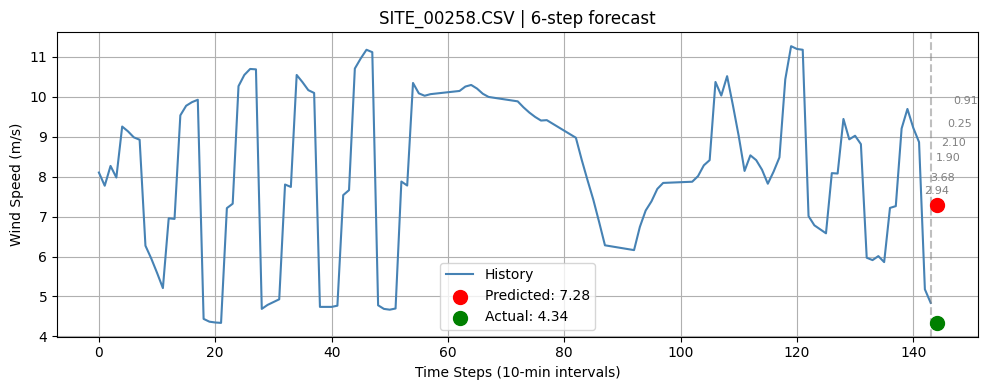

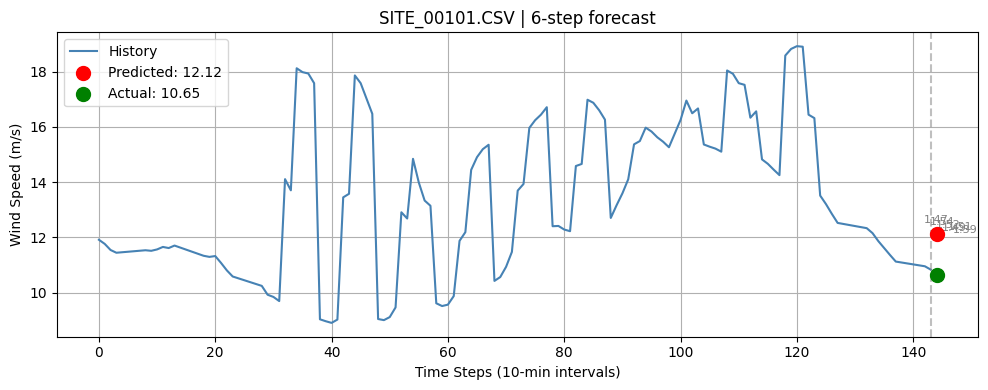

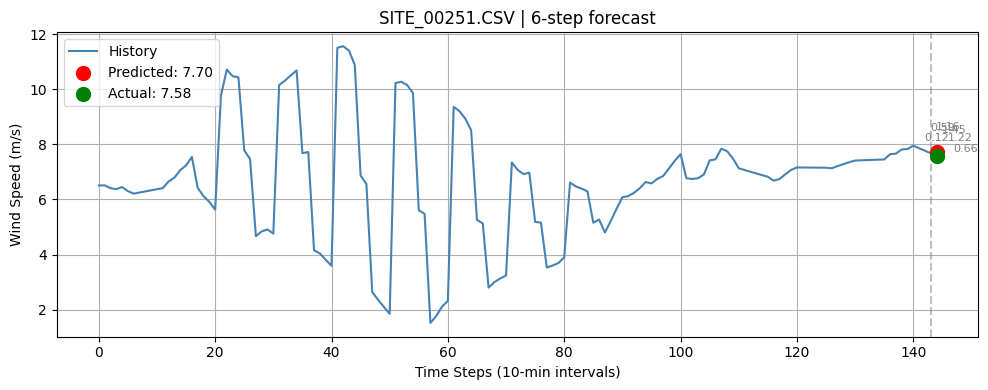

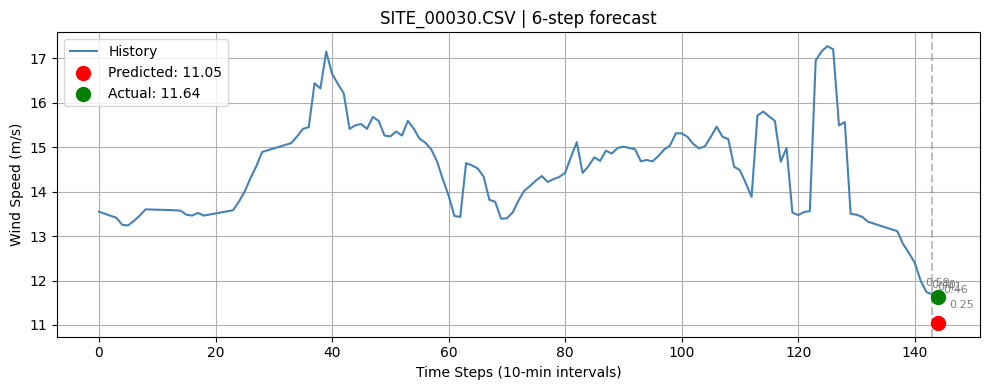

In [22]:
# 1-step plots
sites_sample = random.sample(test_sites, 5)
for s in sites_sample:
    inspect_site_spatial_random(s)

# 6-step plots
for s in sites_sample:
    inspect_site_6step(s)

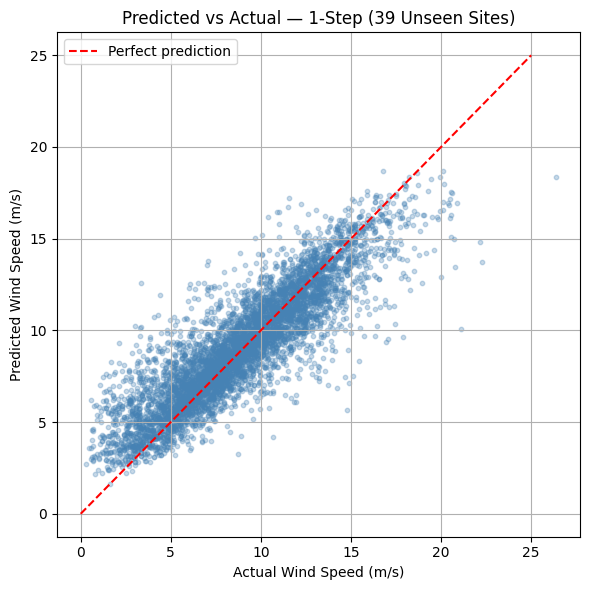

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(trues_arr, preds_arr, alpha=0.3, s=10, color='steelblue')
plt.plot([0,25], [0,25], 'r--', label='Perfect prediction')
plt.xlabel("Actual Wind Speed (m/s)")
plt.ylabel("Predicted Wind Speed (m/s)")
plt.title("Predicted vs Actual — 1-Step (39 Unseen Sites)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

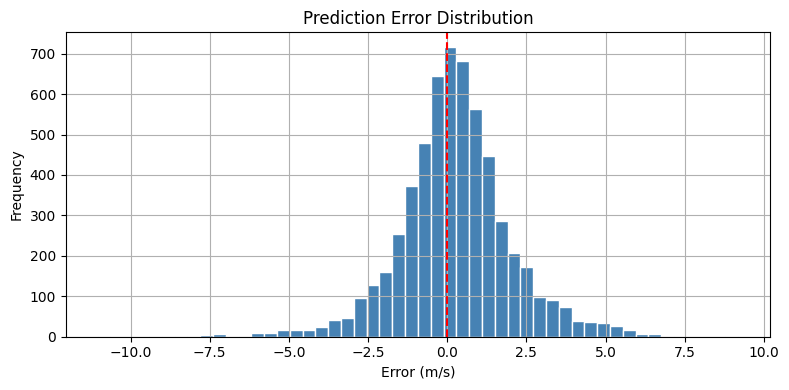

In [24]:
errors = preds_arr - trues_arr
plt.figure(figsize=(8,4))
plt.hist(errors, bins=50, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.title("Prediction Error Distribution")
plt.xlabel("Error (m/s)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

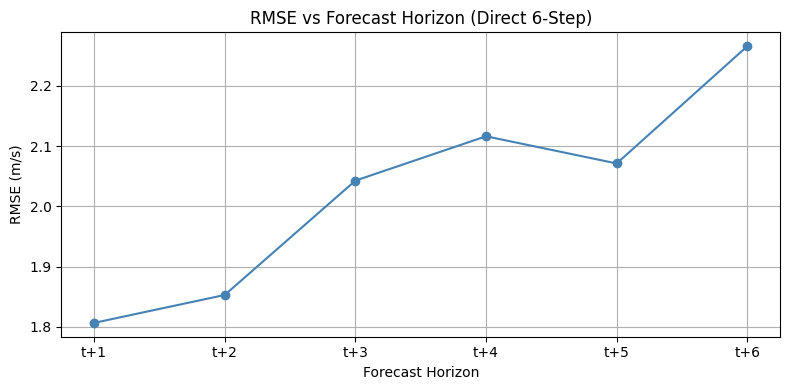

In [25]:
steps    = [f"t+{i+1}" for i in range(6)]
rmse_per = [1.8066, 1.8529, 2.0426, 2.1162, 2.0711, 2.2657]

plt.figure(figsize=(8,4))
plt.plot(steps, rmse_per, marker='o', color='steelblue')
plt.title("RMSE vs Forecast Horizon (Direct 6-Step)")
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE (m/s)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# ==============================
# EXTEND TO 40 TEST SITES
# ==============================
test_sites_40 = test_sites + val_sites[-1:]
print(f"Extended test sites: {len(test_sites_40)}")

# make sure the extra site is scaled
if val_sites[-1] not in site_scalers:
    scale_site(val_sites[-1], global_std)

# ==============================
# 1-STEP EVALUATION (40 SITES)
# ==============================
from sklearn.metrics import r2_score, mean_absolute_error

k_eval           = 4
TEMPORAL_SAMPLES = 150

sq_errors = []
preds     = []
trues     = []

model.eval()
np.random.seed(42)

for idx, test_site in enumerate(test_sites_40):

    print(f"Evaluating site {idx+1}/{len(test_sites_40)}")

    lat_t, lon_t = latlon.get(test_site, (None, None))
    if lat_t is None:
        continue

    dists = []
    for s in train_sites:
        lat, lon = latlon.get(s, (None, None))
        if lat is None:
            continue
        d = haversine(lat_t, lon_t, lat, lon)
        dists.append((s, d))

    neighbors   = [x[0] for x in sorted(dists, key=lambda x: x[1])[:k_eval]]
    batch_sites = neighbors + [test_site]

    series_batch = []
    ts_batch     = []

    for s in batch_sites:
        if s in train_cache:
            series, ts = train_cache[s]
        elif s in val_cache:
            series, ts = val_cache[s]
        elif s in test_cache:
            series, ts = test_cache[s]
        else:
            continue
        series_batch.append(series)
        ts_batch.append(ts)

    if len(series_batch) < 2:
        continue

    valid_batch = batch_sites[:len(series_batch)]
    A = build_graph(valid_batch, k=4)

    max_len = min([len(s) for s in series_batch]) - LOOKBACK - 6
    if max_len <= 0:
        continue

    starts = np.random.randint(0, max_len, TEMPORAL_SAMPLES)

    for start in starts:

        X_list      = []
        y_true_wind = None

        for i, (series, ts) in enumerate(zip(series_batch, ts_batch)):

            window = series[start:start+LOOKBACK, 0]
            power  = series[start:start+LOOKBACK, 1]
            ts_w   = ts[start:start+LOOKBACK]

            roll_mean = pd.Series(window).rolling(12, min_periods=1).mean().values
            roll_std  = pd.Series(window).rolling(12, min_periods=1).std().fillna(0).values
            roll_max  = pd.Series(window).rolling(6,  min_periods=1).max().values
            roll_min  = pd.Series(window).rolling(6,  min_periods=1).min().values

            minutes  = (ts_w.hour*60 + ts_w.minute).values
            sin_day  = np.sin(2*np.pi*minutes/1440)
            cos_day  = np.cos(2*np.pi*minutes/1440)

            doy      = ts_w.dayofyear.values
            sin_year = np.sin(2*np.pi*doy/365)
            cos_year = np.cos(2*np.pi*doy/365)

            lag1  = np.roll(window, 1); lag1[0]  = lag1[1]
            lag2  = np.roll(window, 2); lag2[:2] = lag2[2]
            delta = window - np.roll(window, 1); delta[0] = 0

            lat_s, lon_s = latlon.get(valid_batch[i], (0, 0))
            lat_feat = np.full_like(window, (lat_s or 0) / 90.0)
            lon_feat = np.full_like(window, (lon_s or 0) / 180.0)

            feat = np.stack(
                [window, power, roll_mean, roll_std,
                 sin_day, cos_day, sin_year, cos_year,
                 lag1, lag2, delta,
                 roll_max, roll_min,
                 lat_feat, lon_feat],
                axis=1
            )

            X_list.append(feat)

            if i == len(series_batch) - 1:
                y_true_wind = series[start + LOOKBACK, 0]

        if len(X_list) < 2 or y_true_wind is None:
            continue

        X  = np.stack(X_list, axis=1)[np.newaxis].astype(np.float32)
        xb = torch.from_numpy(X).to(device)

        with torch.no_grad():
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                pred = model(xb, A).cpu().numpy()[0, -1]  # (6,)

        mean_s, std_s = site_scalers[test_site]
        pred_real = float(pred[0]) * float(std_s[0]) + float(mean_s[0])
        true_real = float(y_true_wind) * float(std_s[0]) + float(mean_s[0])

        sq_errors.append((pred_real - true_real) ** 2)
        preds.append(pred_real)
        trues.append(true_real)

preds_arr = np.array(preds)
trues_arr = np.array(trues)

rmse = np.sqrt(np.mean(sq_errors))
mae  = mean_absolute_error(trues_arr, preds_arr)
r2   = r2_score(trues_arr, preds_arr)

mask = trues_arr != 0
mape = np.mean(np.abs((trues_arr[mask] - preds_arr[mask]) / trues_arr[mask])) * 100

within   = np.abs(trues_arr - preds_arr) / (np.abs(trues_arr) + 1e-8)
acc_10   = np.mean(within <= 0.10) * 100
acc_15   = np.mean(within <= 0.15) * 100
acc_20   = np.mean(within <= 0.20) * 100
acc_25   = np.mean(within <= 0.25) * 100
acc_30   = np.mean(within <= 0.30) * 100

abs_errors = np.abs(trues_arr - preds_arr)
acc_1ms  = np.mean(abs_errors <= 1.0) * 100
acc_2ms  = np.mean(abs_errors <= 2.0) * 100
acc_3ms  = np.mean(abs_errors <= 3.0) * 100

persist_rmse = np.sqrt(np.mean((trues_arr[1:] - trues_arr[:-1])**2))
improvement  = ((persist_rmse - rmse) / persist_rmse) * 100

print("=" * 50)
print("       FINAL EVALUATION METRICS")
print("=" * 50)
print(f"  RMSE              : {rmse:.4f} m/s")
print(f"  MAE               : {mae:.4f} m/s")
print(f"  R²                : {r2:.4f}")
print(f"  MAPE              : {mape:.2f} %")
print("-" * 50)
print("  PERCENTAGE ACCURACY")
print(f"  Within 10%        : {acc_10:.2f} %")
print(f"  Within 15%        : {acc_15:.2f} %")
print(f"  Within 20%        : {acc_20:.2f} %")
print(f"  Within 25%        : {acc_25:.2f} %")
print(f"  Within 30%        : {acc_30:.2f} %")
print("-" * 50)
print("  ABSOLUTE ERROR ACCURACY")
print(f"  Within ±1.0 m/s   : {acc_1ms:.2f} %")
print(f"  Within ±2.0 m/s   : {acc_2ms:.2f} %")
print(f"  Within ±3.0 m/s   : {acc_3ms:.2f} %")
print("-" * 50)
print("  BASELINE COMPARISON")
print(f"  Persistence RMSE  : {persist_rmse:.4f} m/s")
print(f"  ST-LSTM RMSE      : {rmse:.4f} m/s")
print(f"  Improvement       : {improvement:.2f} %")
print(f"  Sites evaluated   : {len(test_sites_40)}")
print(f"  Total samples     : {len(sq_errors)}")
print("=" * 50)

# ==============================
# 6-STEP EVALUATION (40 SITES)
# ==============================
from sklearn.metrics import mean_squared_error

all_preds = []
all_trues = []

model.eval()
np.random.seed(42)

for test_site in test_sites_40:

    lat_t, lon_t = latlon.get(test_site, (None, None))
    if lat_t is None:
        continue

    dists = []
    for s in train_sites:
        lat, lon = latlon.get(s, (None, None))
        if lat is None:
            continue
        d = haversine(lat_t, lon_t, lat, lon)
        dists.append((s, d))

    if len(dists) < 4:
        continue

    neighbors   = [x[0] for x in sorted(dists, key=lambda x: x[1])[:4]]
    batch_sites = neighbors + [test_site]

    series_list = []
    ts_list     = []

    for s in batch_sites:
        if s in train_cache:
            series, ts = train_cache[s]
        elif s in val_cache:
            series, ts = val_cache[s]
        elif s in test_cache:
            series, ts = test_cache[s]
        else:
            continue
        series_list.append(series)
        ts_list.append(ts)

    if len(series_list) < 2:
        continue

    valid_batch = batch_sites[:len(series_list)]
    A = build_graph(valid_batch, k=4)

    max_len = min([len(s) for s in series_list]) - LOOKBACK - 6
    if max_len <= 0:
        continue

    starts = np.random.randint(0, max_len, 150)

    for start in starts:

        X_list = []
        y_true = None

        for i, (series, ts) in enumerate(zip(series_list, ts_list)):

            lat_s, lon_s = latlon.get(valid_batch[i], (0, 0))

            X_s, y_s = make_windows(
                series[start:start+LOOKBACK+7],
                ts[start:start+LOOKBACK+7],
                lat_s, lon_s,
                LOOKBACK
            )

            if len(X_s) == 0:
                continue

            X_list.append(X_s[0])

            if i == len(series_list) - 1:
                y_true = y_s[0]

        if len(X_list) < 2 or y_true is None:
            continue

        X  = np.stack(X_list, axis=1)[np.newaxis].astype(np.float32)
        xb = torch.from_numpy(X).to(device)

        with torch.no_grad():
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                pred = model(xb, A).cpu().numpy()[0, -1]

        mean_s, std_s = site_scalers[test_site]
        pred_real = pred   * float(std_s[0]) + float(mean_s[0])
        true_real = y_true * float(std_s[0]) + float(mean_s[0])

        all_preds.append(pred_real)
        all_trues.append(true_real)

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)

print("\n========== 6-STEP METRICS (40 SITES) ==========\n")
for i in range(6):
    rmse = np.sqrt(mean_squared_error(all_trues[:, i], all_preds[:, i]))
    r2   = r2_score(all_trues[:, i], all_preds[:, i])
    print(f"Step {i+1}: RMSE = {rmse:.4f}, R² = {r2:.4f}")

rmse_all = np.sqrt(mean_squared_error(all_trues.flatten(), all_preds.flatten()))
r2_all   = r2_score(all_trues.flatten(), all_preds.flatten())

print("\n---------- OVERALL ----------")
print(f"RMSE (all steps): {rmse_all:.4f}")
print(f"R²   (all steps): {r2_all:.4f}")
print(f"Sites evaluated : {len(test_sites_40)}")

Extended test sites: 40
Evaluating site 1/40
Evaluating site 2/40
Evaluating site 3/40
Evaluating site 4/40
Evaluating site 5/40
Evaluating site 6/40
Evaluating site 7/40
Evaluating site 8/40
Evaluating site 9/40
Evaluating site 10/40
Evaluating site 11/40
Evaluating site 12/40
Evaluating site 13/40
Evaluating site 14/40
Evaluating site 15/40
Evaluating site 16/40
Evaluating site 17/40
Evaluating site 18/40
Evaluating site 19/40
Evaluating site 20/40
Evaluating site 21/40
Evaluating site 22/40
Evaluating site 23/40
Evaluating site 24/40
Evaluating site 25/40
Evaluating site 26/40
Evaluating site 27/40
Evaluating site 28/40
Evaluating site 29/40
Evaluating site 30/40
Evaluating site 31/40
Evaluating site 32/40
Evaluating site 33/40
Evaluating site 34/40
Evaluating site 35/40
Evaluating site 36/40
Evaluating site 37/40
Evaluating site 38/40
Evaluating site 39/40
Evaluating site 40/40
       FINAL EVALUATION METRICS
  RMSE              : 1.8109 m/s
  MAE               : 1.3127 m/s
  R²   